# Cyclone driven Near Inertial Analysis

# Modules

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import cartopy as cr # for geographic mapping
import cartopy.crs as ccrs # for map projections
import matplotlib.pyplot as plt # plotting tool
import matplotlib
import seaborn as sns
import cartopy.feature as cfeature # to add coastlines, land and ocean
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cmocean
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as mticker
import xskillscore as xs
import os
import glob
import matplotlib.patches as patches
from scipy.stats import norm, normaltest, shapiro
from scipy.stats import t as t_fun
from eofs.xarray import Eof
plt.rcParams["font.family"] = "Times New Roman"
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
from datetime import datetime
from scipy import signal

# Functions

In [11]:
def spec_rot(u, v):
    fu, fv = list(map(np.fft.fft, (u, v)))
    pu = fu * np.conj(fu)
    pv = fv * np.conj(fv)
    puv = fu.real * fv.real + fu.imag * fv.imag
    quv = -fu.real * fv.imag + fv.real * fu.imag
    cw = (pu + pv - 2 * quv) / 4.
    ccw = (pu + pv + 2 * quv) / 4.
    N = len(u)
    F = np.arange(0, N) / N
    F = np.fft.fftfreq(N, d=6) 
    return puv, quv, cw, ccw,F

import numpy as np



def lowpass(b,t):
    import xrscipy.signal as dsp
    a=b.copy()
    tim=a.time
    a['time']=np.arange(len(a['time']))
    ff=dsp.filters.lowpass(a, 1/t, order=5,dim='time')
    ff['time']=tim
    a['time']=tim
    return ff
    
def qhat_xr(a):
    dat=a.copy()#.squeeze()
    tim=np.arange(1,len(dat.time)+1)
    dat['time']=tim
    pf=dat.polyfit('time',1)
    fit=xr.polyval(xr.DataArray(tim,dims=['time']),pf).polyfit_coefficients
    fit['time']=a.time
    return fit,pf
    
def weight_gl(ds):
    weights = np.cos(np.deg2rad(ds.lat))
    weights.name = "weights"
    ds_weighted = ds.weighted(weights)
    weighted_mean = ds_weighted.mean(("lon", "lat"))
    return weighted_mean
    
def dict_maker(keys, lists):
        dic = {}
        for i, n in enumerate(keys):
            dic[n] = lists[i]
        return dic
    
def ren_fun_sck(dc,decode=False):
    if decode == False:
        ds=xr.open_dataset(dc)
    else:
        ds=xr.open_dataset(dc,decode_times=False)
    for i in list(ds.coords.keys()):
        if ds[i].attrs['axis']=='X':
            ds=ds.rename({i:'lon'})
        elif ds[i].attrs['axis']=='Y':
            ds=ds.rename({i:'lat'})
        elif ds[i].attrs['axis']=='Z':
            ds=ds.rename({i:'depth'})
        else :
            ds=ds.rename({i:'time'})
    return ds
def find_path(directory, extension):
    if not extension.startswith('.'):
        extension = '.' + extension
    search_pattern = os.path.join(directory, '*' + extension)
    files_with_extension = glob.glob(search_pattern)   
    return files_with_extension

from scipy import stats
def sta(a,b):
    slope, intercept, r_value, p_value, std_err = stats.linregress(a,b)
    return slope
def sta_p(a,b):
    slope, intercept, r_value, p_value, std_err = stats.linregress(a,b)
    return p_value
def regression_vec_n(obj,obj2, dim):
    # note: apply always moves core dimensions to the end
    return [xr.apply_ufunc(
        sta, obj,obj2, input_core_dims= [ [dim],[dim] ],
        output_core_dims=[[]],vectorize=True),
    xr.apply_ufunc(
        sta_p, obj,obj2, input_core_dims= [ [dim],[dim] ],
        output_core_dims=[[]],vectorize=True)]
def t_idxr(dat):
    return [str(dat.compute().time.dt.year[0].data),
            str(dat.compute().compute().time.dt.year[-1].data)]

def linreg_slope(xx,t1,t2,dim):
    xx=xx.sel(time=slice(t1,t2))
    xn=np.arange(len(xx.time))
    return regression_vec_n(xn,xx,'time')

def fig_beauty(ax,n,m,c,xx,cs=0.5,lc='grey'):
    '''
       sets the aesthetics of the figure
       parameter :
       ============
       ax : axis
              
       n,m : number of rows and columns
       
       c   : iterator
       
       xx  : label size
              
       cs  : cost line width
       ocean: boolean
              whether to add ocean 
    '''
    ax.add_feature(cfeature.LAND,alpha=1,color=lc,zorder=1)
    ax.add_feature(cfeature.COASTLINE,zorder=2,lw=cs)
    ax.set_ylabel('')
    ax.set_yticklabels('')
    gl=ax.gridlines(color='black',linestyle='--',alpha=0.15,linewidth=0.5)
    gl.xlabel_style = {'size': xx, 'color': 'black'}
    gl.ylabel_style = {'size': xx, 'color': 'black'}
    aa=[]
    for x in range(n):
        for y in range(m):
            aa.append([x,y])
    indices=aa[c]
    
    if indices[0] == n-1:
    	gl.bottom_labels=True
    if indices[1] == 0:
    	gl.left_labels = True
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

import statsmodels.api as sm
def ci_stat(dummy_data):
    if np.isnan(dummy_data).any():
        return xr.DataArray(np.nan)
    import statsmodels.api as sm
    acorr = sm.tsa.acf(dummy_data, nlags = len(dummy_data)-1)
    dummy_xr = abs(xr.DataArray(acorr,coords={'lag':np.arange(len(acorr))})-0.37).argmin().data.item()
    deg_fr = len(dummy_data)/(dummy_xr*2)
    return xr.DataArray((stats.linregress(np.arange(len(dummy_data)),dummy_data)[4]*stats.t.ppf(1-0.025,deg_fr)))*12*1000
def ci(ds):
    obj=np.arange(len(ds.time))
    result1 = xr.apply_ufunc(sta, obj,ds, input_core_dims= [ ['time'],['time'] ],output_core_dims=[[]],vectorize=True)
    result2 = xr.apply_ufunc(ci_stat, ds, input_core_dims=[['time']], output_core_dims=[[]], vectorize=True)
    return result1,result2

class LinearRegression:
    
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
    
    def fit(self, X, y=None):
        
        X = self._prepare_X(X)
        n, p = X.shape
        
        self.n = n
        self.p = p
        
        C = np.linalg.inv(X.T.dot(X))
        self.C = C

        betas = C.dot(X.T.dot(y))
        self.betas = betas
        
        epsilon = y - X.dot(betas)
        sse = np.sum(epsilon * epsilon)
        
        sigma_squared = sse / (n - p)
        self.sigma_squared = sigma_squared
        
        sigma = np.sqrt(sigma_squared)
        self.sigma = sigma
        
        V = C * sigma_squared
        self.V = V

        sigma_betas = np.sqrt(np.diag(V))
        self.sigma_betas = sigma_betas
        
        pvalues = t_fun.sf(abs(betas) / sigma_betas, (n - p)) * 2.0
        self.pvalues = pvalues
    
    def predict(self, X, y=None):
        X = self._prepare_X(X)
        y_pred = X.dot(self.betas)
        return y_pred
    
    def fit_predict(self, X, y=None):
        self.fit(X, y)
        y_pred = self.predict(X)
        return y_pred
    
    def predict_confidence_interval(self, X, alpha=0.05):
        X = self._prepare_X(X)
        t_value = t_fun.isf(alpha/2, self.n - self.p)
        sigma_pred = np.sqrt(self.sigma_squared * np.sum(X.dot(self.C) * X, axis=1))
        return t_value * sigma_pred
    
    def _prepare_X(self, X):
        
        X = np.array(X)
        if len(X.shape) == 1:
            X = np.atleast_2d(X).reshape((-1, 1))
        
        if self.fit_intercept:
            ones = np.ones((X.shape[0], 1))
            X = np.column_stack((ones, X))
        
        else:
            pass

        return X
    
    def r2_score(self, X, y):
        
        y_pred = self.predict(X)
        epsilon = y_pred - y
        sse = np.sum(epsilon * epsilon)
        
        y_mean = np.mean(y)
        mean_res = y_mean - y
        sst = np.sum(mean_res * mean_res)
        
        return 1 - sse / sst
        
def perform_linear_regression(x1, x2,x3,x4, y):
    X = np.column_stack((x1, x2,x3,x4))
    model = LinearRegression()
    model.fit(X, y)

    # Get beta coefficients
    betas = model.betas

    return betas,model.pvalues

import xarray as xr
def sta0(a,b,c,d,e):
    a=perform_linear_regression(a.data,b.data,c.data,d.data,e.data)[0]
    return a[0]
def sta1(a,b,c,d,e):
    a=perform_linear_regression(a.data,b.data,c.data,d.data,e.data)[0]
    return a[1]
def sta2(a,b,c,d,e):
    a=perform_linear_regression(a.data,b.data,c.data,d.data,e.data)[0]
    return a[2]
def sta3(a,b,c,d,e):
    a=perform_linear_regression(a.data,b.data,c.data,d.data,e.data)[0]
    return a[3]
def sta4(a,b,c,d,e):
    a=perform_linear_regression(a.data,b.data,c.data,d.data,e.data)[0]
    return a[4]
    
def regression_vec_ml(obj,obj2,obj3,obj4,obj5, dim):
    # note: apply always moves core dimensions to the end
    intr=xr.apply_ufunc(
        sta0, obj,obj2,obj3,obj4,obj5, input_core_dims= [ [dim],[dim],[dim],[dim],[dim] ],
        output_core_dims=[[]],vectorize=True)
    a=xr.apply_ufunc(
        sta1, obj,obj2,obj3,obj4,obj5, input_core_dims= [ [dim],[dim],[dim],[dim],[dim] ],
        output_core_dims=[[]],vectorize=True)
    b=xr.apply_ufunc(
        sta2, obj,obj2,obj3,obj4,obj5, input_core_dims= [ [dim],[dim],[dim],[dim],[dim] ],
        output_core_dims=[[]],vectorize=True)
    c=xr.apply_ufunc(
        sta3, obj,obj2,obj3,obj4,obj5, input_core_dims= [ [dim],[dim],[dim],[dim],[dim] ],
        output_core_dims=[[]],vectorize=True)
    d=xr.apply_ufunc(
        sta4, obj,obj2,obj3,obj4,obj5, input_core_dims= [ [dim],[dim],[dim],[dim],[dim] ],
        output_core_dims=[[]],vectorize=True)
    intr.name='intercept'
    a.name='First'
    b.name='Second'
    c.name='Third'
    d.name='Fourth'
    return xr.merge([intr,a,b,c,d])

def roll_sel(ds,tt,std=False,detr=False,anom=True):
    dx=ds.copy()
    if anom==True:
        dx=dx.groupby('time.month')-dx.groupby('time.month').mean()
        
    if detr == True:
        dx=dx-qhat_xr(dx)[0]
    else:
        dx=dx
    yr=dx.time.dt.year.data[0]
    ln=len(dx.time)
    dti=pd.date_range(start='15-jan-'+str(yr),freq='M',periods=ln)
    dx['time']=dti
    xxx=int((tt-1)/2)
    dx=lowpass(dx,tt).isel(time=range(xxx,len(dx.time)-xxx))
    if std == True:
        dx=dx/dx.std()
    else:
        dx=dx
    return dx
def deseason(dx,detr=True):
    ds=dx.groupby('time.month')-dx.groupby('time.month').mean()
    if detr == True:
        ds=ds-qhat_xr(ds)[0]
    return ds

def quiver_pl(ax,a,b,sl=0.05):
    n=1
    lon,lat=np.meshgrid(a.lon,a.lat)
    pl=ax.quiver(lon[::n,::n],lat[::n,::n],a[::n,::n],b[::n,::n],scale=sl,width=0.002)
    return pl
def corr_cal(a,b):
    return xs.pearson_r(a,b.interp(time=a.time),skipna=True)

from scipy.signal import butter, sosfilt, sosfiltfilt
def butter_bandpass_sos(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')
    return sos

def butter_lowpass_filter_sos(data, axis, cutoff, fs, order=5, filtopt='acausal'):
    sos = butter_lowpass_sos(cutoff, fs, order=order)
    if filtopt == 'causal':
        y = lfilter(b, a, data, axis)
    else:
        y = sosfiltfilt(sos, data, axis=axis)
    return y

def butter_bandpass_filter_sos(data, axis, lowcut, highcut, fs, order=8, filtopt='acausal'):
    sos = butter_bandpass_sos(lowcut, highcut, fs, order=order)
    if filtopt == 'causal':
        y = lfilter(b, a, data, axis)
    else:
        y = sosfiltfilt(sos, data, axis=axis)
    return y

def bandpass(b,t1,t2):
    import xrscipy.signal as dsp
    a=b.copy()
    tim=a.time
    a['time']=np.arange(len(a['time']))
    ff=dsp.filters.bandpass(a, 1/t2,1/t1,dim='time')
    ff['time']=tim
    a['time']=tim
    return ff   

import matplotlib.patches as patches
def box_map(l1,l2,la1,la2,ax,lww=1.5,lss='-',c='black',al=1):
    rect = patches.Rectangle((l1, la1), l2-l1, la2-la1, lw=lww,ls=lss, edgecolor=c, facecolor='none', zorder=3,alpha=al)
    ax.add_patch(rect)

def cor(lat):
    Omega = 7.292e-5 
    phi = np.deg2rad(lat)
    f = 2 * Omega * np.sin(phi)
    T = 2 * np.pi / f     # seconds
    T_hours = T / 3600    # hours
    return T_hours


def ke_comps(u,v,lat):
    thour = cor(lat)
    KE= KinEn(u,v)

    u_bp = butter_bandpass_filter_sos(
    u,
    axis=0,
    lowcut=1/(thour*1.2),
    highcut=1/(thour*0.8),
    fs=1/6,
    order=8,
    filtopt='acausal')

    v_bp = butter_bandpass_filter_sos(
    v,
    axis=0,
    lowcut=1/(thour*1.2),
    highcut=1/(thour*0.8),
    fs=1/6,
    order=8,
    filtopt='acausal')
    KE_bp = KinEn(u_bp,v_bp)
    
    KE_bp = xr.DataArray(KE_bp,coords={'time':KE.time})
    return KE,KE_bp

def inertial_filter(u,v,lat):
    thour = cor(lat)

    u_bp = butter_bandpass_filter_sos(
    u,
    axis=0,
    lowcut=1/(thour*1.2),
    highcut=1/(thour*0.8),
    fs=1/6,
    order=8,
    filtopt='acausal')

    v_bp = butter_bandpass_filter_sos(
    v,
    axis=0,
    lowcut=1/(thour*1.2),
    highcut=1/(thour*0.8),
    fs=1/6,
    order=8,
    filtopt='acausal')
    u_bp=xr.DataArray(u_bp,coords=u.coords)

    return xr.DataArray(u_bp,coords=u.coords),xr.DataArray(v_bp,coords=v.coords)

def spec_rot(u, v):
    fu, fv = list(map(np.fft.fft, (u, v)))
    pu = fu * np.conj(fu)
    pv = fv * np.conj(fv)
    puv = fu.real * fv.real + fu.imag * fv.imag
    quv = -fu.real * fv.imag + fv.real * fu.imag
    cw = (pu + pv - 2 * quv) / 4.
    ccw = (pu + pv + 2 * quv) / 4.
    N = len(u)
    F = np.arange(0, N) / N
    F = np.fft.fftfreq(N, d=6) 
    return puv, quv, cw, ccw,F

## Figure 4

0
1
2


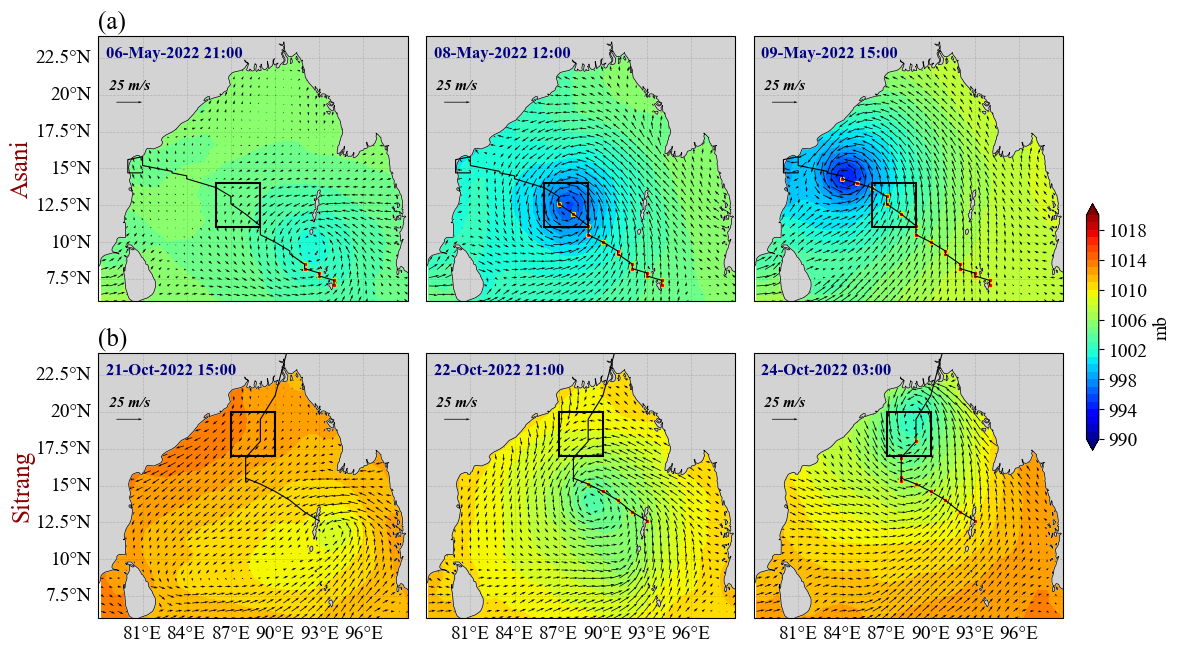

In [45]:
plt.rcParams.update({
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal'})
ds_u10=ren_fun_sck('../CYCLONE-NIW/Data/jra_u10.nc')
ds_v10=ren_fun_sck('../CYCLONE-NIW/Data/jra_v10.nc')
ds_psl=ren_fun_sck('../CYCLONE-NIW/Data/psl.nc')

u_aug=ds_u10.u10.sel(time=slice('05-may-2022','12-may-2022')).sel(lon=slice(78,100),lat=slice(5,25))
v_aug=ds_v10.v10.sel(time=slice('05-may-2022','12-may-2022')).sel(lon=slice(78,100),lat=slice(5,25))
psl_aug=ds_psl.psl.sel(time=slice('05-may-2022','12-may-2022')).sel(lon=slice(78,100),lat=slice(5,25))
df=pd.read_csv('../CYCLONE-NIW/bio2022/bio022022.dat',header=None)
lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
time_str = pd.to_datetime(u_aug.time).strftime("%d-%b-%Y %H:00")

titl=[[i][0] for i in time_str]
cycl_dt=[]
for dtn in df[2]:
        date_new=str(dtn)
        cycl_dt.append(pd.to_datetime(date_new[0:4]+'-'+date_new[4:6]+'-'+date_new[6:8]+' '+date_new[8:10]).strftime("%d-%b-%Y %H:00"))
lon_lat_date=pd.DataFrame([lon,lat,cycl_dt]).T.set_index(2)
fig,ax = plt.subplots(2,3, figsize=(15,10), subplot_kw={'projection': ccrs.PlateCarree()})
i=10
fig.subplots_adjust(wspace=0.06,hspace=-0.3)
for n,axn in enumerate(ax.flat[0:3]):
    print(n)
    i=[15,28,37,48][n]
    pl=(psl_aug.isel(time=i)/100).plot.contourf(levels=np.arange(990,1021,1),cmap='jet',add_colorbar=False,extend='both',ax=axn)
    #axn.set_title(['(a)','(b)','(c)'][n])
    axn.set_title('')
    qn=quiver_pl(axn,u_aug.isel(time=i),v_aug.isel(time=i),sl=300)
    axn.quiverkey(qn,0.1,0.75,25,'25 m/s',zorder=5,fontproperties={'size':11,'style':'oblique','weight':'bold'})
    fig_beauty(axn,2,3,n,14,lc='lightgrey')
    axn.plot(lon,lat,lw=0.8,color='black')
    fname = f"{i+1:03d}.jpg"
    axn.text(78.5,22.5,titl[i],fontsize=12,fontweight='bold',color='navy')
    n=0
    for dtn in cycl_dt:
        if pd.to_datetime(dtn) <= pd.to_datetime(titl[i]):
        #print(lon_lat_date[0][n],lon_lat_date[0][n],titl[i])
            axn.scatter(lon_lat_date.loc[dtn][0],lon_lat_date.loc[dtn][1],color='red',edgecolor='yellow',s=10,linewidths=0.5)
            n=n+1
    axn.set_extent([78,99,6,24])
    box_map(86,89,11,14,axn)
    
ax[0,0].text(72,15,'Asani',color='darkred',va='center',rotation=90,fontsize=18)

u_aug=ds_u10.u10.sel(time=slice('21-oct-2022','26-oct-2022')).sel(lon=slice(78,100),lat=slice(5,25))
v_aug=ds_v10.v10.sel(time=slice('21-oct-2022','26-oct-2022')).sel(lon=slice(78,100),lat=slice(5,25))
psl_aug=ds_psl.psl.sel(time=slice('21-oct-2022','26-oct-2022')).sel(lon=slice(78,100),lat=slice(5,25))
df=pd.read_csv('../CYCLONE-NIW/bio2022/bio052022.dat',header=None)
lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
time_str = pd.to_datetime(u_aug.time).strftime("%d-%b-%Y %H:00")
titl=[[i][0] for i in time_str]
cycl_dt=[]
for dtn in df[2]:
        date_new=str(dtn)
        cycl_dt.append(pd.to_datetime(date_new[0:4]+'-'+date_new[4:6]+'-'+date_new[6:8]+' '+date_new[8:10]).strftime("%d-%b-%Y %H:00"))
lon_lat_date=pd.DataFrame([lon,lat,cycl_dt]).T.set_index(2)
n=0



i=10

for n,axn in enumerate(ax.flat[3:6]):
    i=[5,15,25,30][n]
    pl=(psl_aug.isel(time=i)/100).plot.contourf(levels=np.arange(990,1021,1),cmap='jet',add_colorbar=False,extend='both',ax=axn)
    qn=quiver_pl(axn,u_aug.isel(time=i),v_aug.isel(time=i),sl=300)
    axn.quiverkey(qn,0.1,0.75,25,'25 m/s',zorder=5,fontproperties={'size':11,'style':'oblique','weight':'bold'})
    fig_beauty(axn,2,3,n+3,14,lc='lightgrey')
    axn.plot(lon,lat,lw=0.8,color='black')
    fname = f"{i+1:03d}.jpg"
    axn.text(78.5,22.5,titl[i],fontsize=12,fontweight='bold',color='navy')
    axn.set_title('')
    n=0
    for dtn in cycl_dt:
        if pd.to_datetime(dtn) <= pd.to_datetime(titl[i]):
        #print(lon_lat_date[0][n],lon_lat_date[0][n],titl[i])
            axn.scatter(lon_lat_date.loc[dtn][0],lon_lat_date.loc[dtn][1],color='red',edgecolor='yellow',s=10,linewidths=0.5)
            n=n+1
    axn.set_extent([78,99,6,24])
    box_map(87,90,17,20,axn)
axn=ax.flat
for n in range(6):
    axn[n].set_title(['(a)','','','(b)','',''][n],loc='left')
cbar=fig.colorbar(pl,ax=ax[:,:],shrink=0.32,pad=0.02)
ax[1,0].text(72,15,'Sitrang',color='darkred',va='center',rotation=90,fontsize=18)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=14)
cbar.set_label('mb', fontsize=14)
plt.savefig('FIGURE/Figure4.jpg',bbox_inches='tight',dpi=800)

## Figure S4

In [49]:
ds_u10=ren_fun_sck('../CYCLONE-NIW/Data/jra_u10.nc').sel(time=slice('05-may-2022','15-may-2022')).u10
ds_v10=ren_fun_sck('../CYCLONE-NIW/Data/jra_v10.nc').sel(time=slice('05-may-2022','15-may-2022')).v10
asani=np.sqrt(ds_u10.sel(lon=slice(86,89),lat=slice(11,14)).mean(['lon','lat'])**2 + ds_v10.sel(lon=slice(86,89),lat=slice(11,14)).mean(['lon','lat'])**2)

ds_u10=ren_fun_sck('../CYCLONE-NIW/Data/jra_u10.nc').sel(time=slice('20-oct-2022','30-oct-2022')).u10
ds_v10=ren_fun_sck('../CYCLONE-NIW/Data/jra_v10.nc').sel(time=slice('20-oct-2022','30-oct-2022')).v10
sitrang=np.sqrt(ds_u10.sel(lon=slice(87,90),lat=slice(17,20)).mean(['lon','lat'])**2 + ds_v10.sel(lon=slice(87,90),lat=slice(17,20)).mean(['lon','lat'])**2)

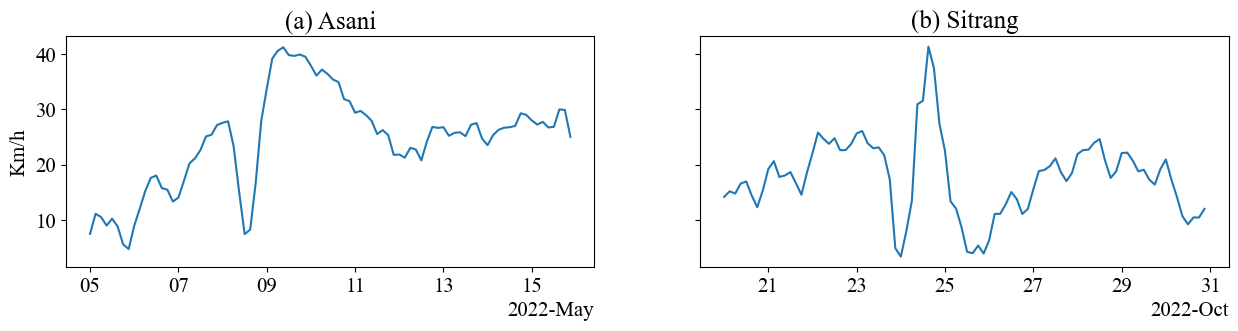

In [50]:
plt.rcParams['font.size']=15
fig,ax = plt.subplots(1,2,figsize=(15,3),sharey=True)
(asani*3.6).plot(ax=ax[0],lw=1.5)
(sitrang*3.6).plot(ax=ax[1],lw=1.5)
ax[0].set_title('(a) Asani')
ax[1].set_title('(b) Sitrang')
ax[0].set_xlabel('')
ax[0].set_ylabel('Km/h')
ax[1].set_xlabel('')
plt.savefig('FIGURE/S4.jpg',bbox_inches='tight',dpi=800)

## Figure S5

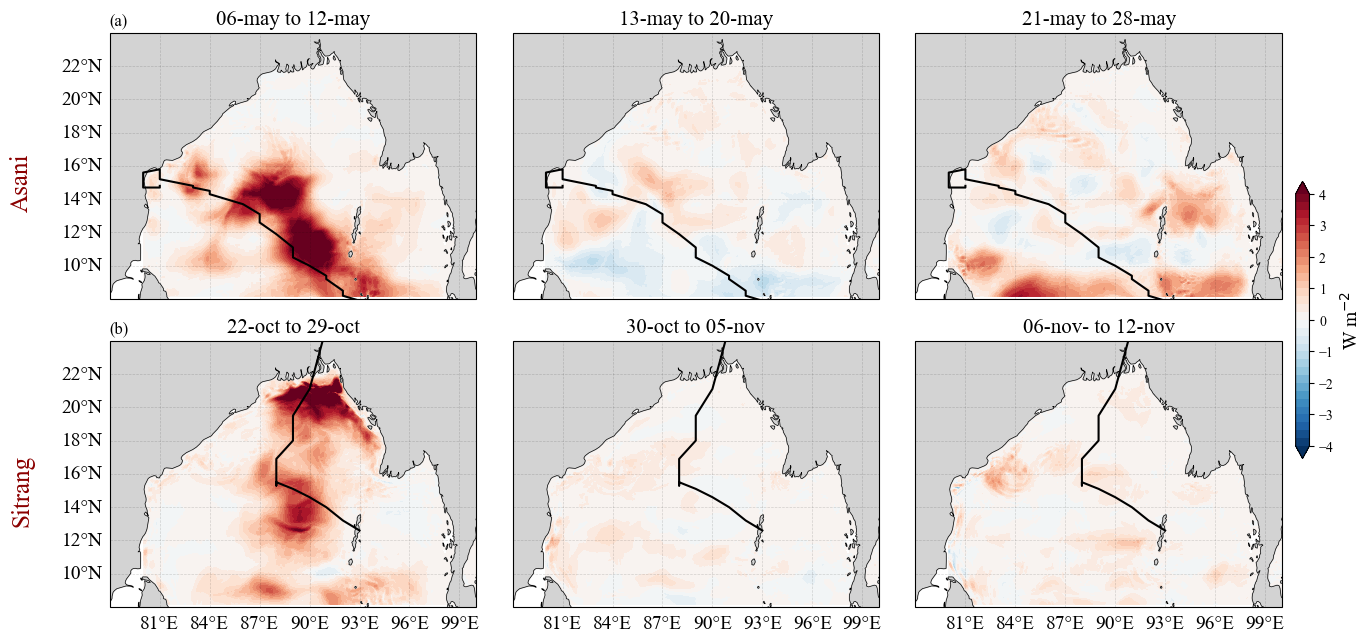

In [5]:
wwork_asani1=ren_fun_sck('WWORK/WWORK_ASANI.nc')['__xarray_dataarray_variable__'].sel(time=slice('06-may-2022','12-may-2022')).mean('time')
wwork_asani2=ren_fun_sck('WWORK/WWORK_ASANI.nc')['__xarray_dataarray_variable__'].sel(time=slice('13-may-2022','20-may-2022')).mean('time')
wwork_asani3=ren_fun_sck('WWORK/WWORK_ASANI.nc')['__xarray_dataarray_variable__'].sel(time=slice('21-may-2022','28-may-2022')).mean('time')

wwork_sitrang1=ren_fun_sck('WWORK/WWORK_SITRANG.nc')['__xarray_dataarray_variable__'].sel(time=slice('22-oct-2022','29-oct-2022')).mean('time')
wwork_sitrang2=ren_fun_sck('WWORK/WWORK_SITRANG.nc')['__xarray_dataarray_variable__'].sel(time=slice('30-oct-2022','05-nov-2022')).mean('time')
wwork_sitrang3=ren_fun_sck('WWORK/WWORK_SITRANG.nc')['__xarray_dataarray_variable__'].sel(time=slice('06-nov-2022','12-nov-2022')).mean('time')

datas=[wwork_asani1,wwork_asani2,wwork_asani3,wwork_sitrang1,wwork_sitrang2,wwork_sitrang3]

fig,ax = plt.subplots(2,3, figsize=(18,12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=-0.5,wspace=0.1)
axn=ax.flat

for i in range(6):
    pl=datas[i].plot.contourf(levels=np.arange(-4,4.25,0.25),ax=axn[i],add_colorbar=False,extend='both')
    fig_beauty(axn[i],2,3,i,14,lc='lightgrey')
    axn[i].set_extent([78,100,8,24])
    if i < 3:
        axn[i].set_title(['06-may to 12-may','13-may to 20-may','21-may to 28-may'][i],fontsize=15)
        df=pd.read_csv('../CYCLONE-NIW/bio2022/bio022022.dat',header=None)
        lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
        lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
        axn[i].plot(lon,lat,color='black',lw=1.5)
    else:
        axn[i].set_title(['22-oct to 29-oct','30-oct to 05-nov','06-nov- to 12-nov'][i-3],fontsize=15)
        df=pd.read_csv('../CYCLONE-NIW/bio2022/bio052022.dat',header=None)
        lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
        lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
        axn[i].plot(lon,lat,color='black',lw=1.5)
for n in range(6):
    axn[n].set_title(['(a)','','','(b)','',''][n],loc='left')

ax[0,0].text(72,15,'Asani',color='darkred',va='center',rotation=90,fontsize=18)
ax[1,0].text(72,15,'Sitrang',color='darkred',va='center',rotation=90,fontsize=18)
cbar=plt.colorbar(pl,ax=ax[:,:],shrink=0.3,pad=0.01)
cbar.ax.minorticks_off()
cbar.set_label('W m$^{-2}$', fontsize=14)
plt.savefig('FIGURE/S5.jpg',bbox_inches='tight',dpi=800)

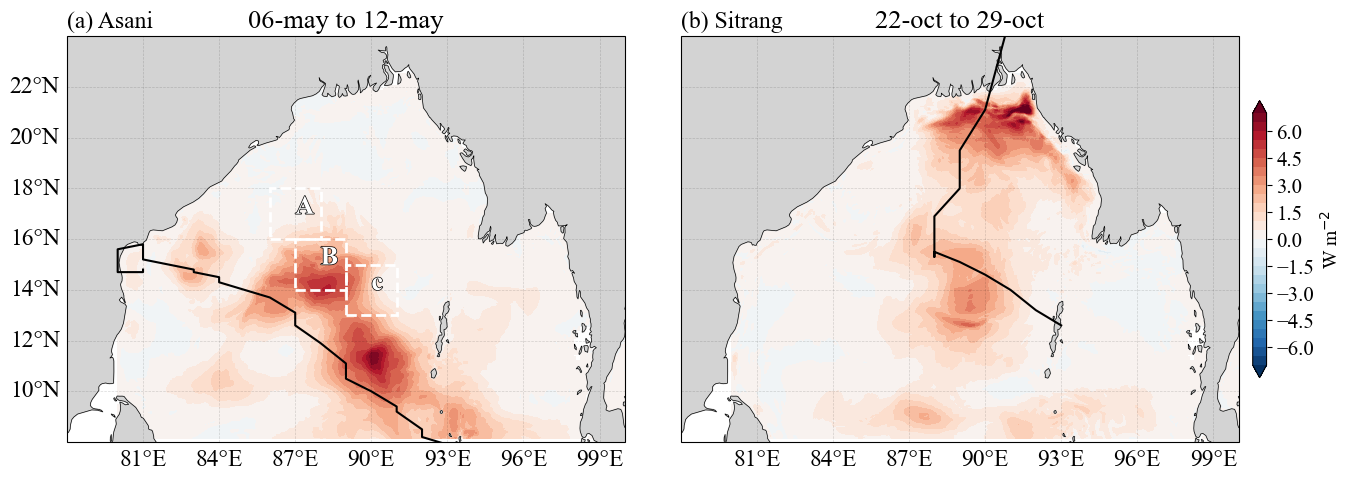

In [66]:
fig,ax = plt.subplots(1,2, figsize=(18,12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=-0.5,wspace=0.1)
axn=ax.flat

i=0
pl=datas[i].plot.contourf(levels=np.arange(-7,7.5,0.5),ax=axn[i],add_colorbar=False,extend='both')
fig_beauty(axn[0],1,2,0,17,lc='lightgrey')
axn[i].set_extent([78,100,8,24])
axn[i].set_title('06-may to 12-may',fontsize=19)
df=pd.read_csv('../CYCLONE-NIW/bio2022/bio022022.dat',header=None)
lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
axn[i].plot(lon,lat,color='black',lw=1.5)
box_map(86,88,16,18,axn[i],c='white',lss='--',lww=2)
axn[i].text(87, 17, 'A',fontsize=19,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1, foreground='black'),pe.Normal()])
box_map(87,89,14,16,axn[i],c='white',lss='--',lww=2)
axn[i].text(88, 15, 'B',fontsize=19,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1, foreground='black'),pe.Normal()])
box_map(89,91,13,15,axn[i],c='white',lss='--',lww=2)
axn[i].text(90, 14, 'c',fontsize=19,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1, foreground='black'),pe.Normal()])

pl=datas[3].plot.contourf(levels=np.arange(-7,7.5,0.5),ax=axn[1],add_colorbar=False,extend='both')
axn[1].set_title('22-oct to 29-oct',fontsize=19)
df=pd.read_csv('../CYCLONE-NIW/bio2022/bio052022.dat',header=None)
lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
axn[1].plot(lon,lat,color='black',lw=1.5)
fig_beauty(axn[1],1,2,1,17,lc='lightgrey')
axn[1].set_extent([78,100,8,24])
for n in range(2):
    axn[n].set_title(['(a) Asani','(b) Sitrang','','(b)','',''][n],loc='left',fontsize=17)


cbar=plt.colorbar(pl,ax=ax[:],shrink=0.3,pad=0.01)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=15)
cbar.set_label('W m$^{-2}$', fontsize=14)
#plt.savefig('FIGURE/S5_v1.jpg',bbox_inches='tight',dpi=800)

## Figure 5

In [24]:
NIKE_asani=ren_fun_sck('NIKE_50/NIKE_ASANI_DIN.nc').NIKE_DIN.sel(time=slice('06-may-2022','28-may-2022')).mean('time')
BLD_asani=ren_fun_sck('mld/asani_mld.nc').ILD.sel(time=slice('06-may-2022','28-may-2022')).mean('time')-ren_fun_sck('mld/asani_mld.nc').MLD.sel(time=slice('06-may-2022','28-may-2022')).mean('time')
SALT_asani=ren_fun_sck('SALT/asani_salt.nc').SALT.sel(time=slice('06-may-2022','28-may-2022')).mean('time')

NIKE_sitrang=ren_fun_sck('NIKE_50/NIKE_SITRANG_50.nc').NIKE_DIN.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time')
BLD_sitrang=ren_fun_sck('mld/sitrang_mld.nc').ILD.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time')-ren_fun_sck('mld/sitrang_mld.nc').MLD.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time')
SALT_sitrang=ren_fun_sck('SALT/sitrang_salt.nc').SALT.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time')

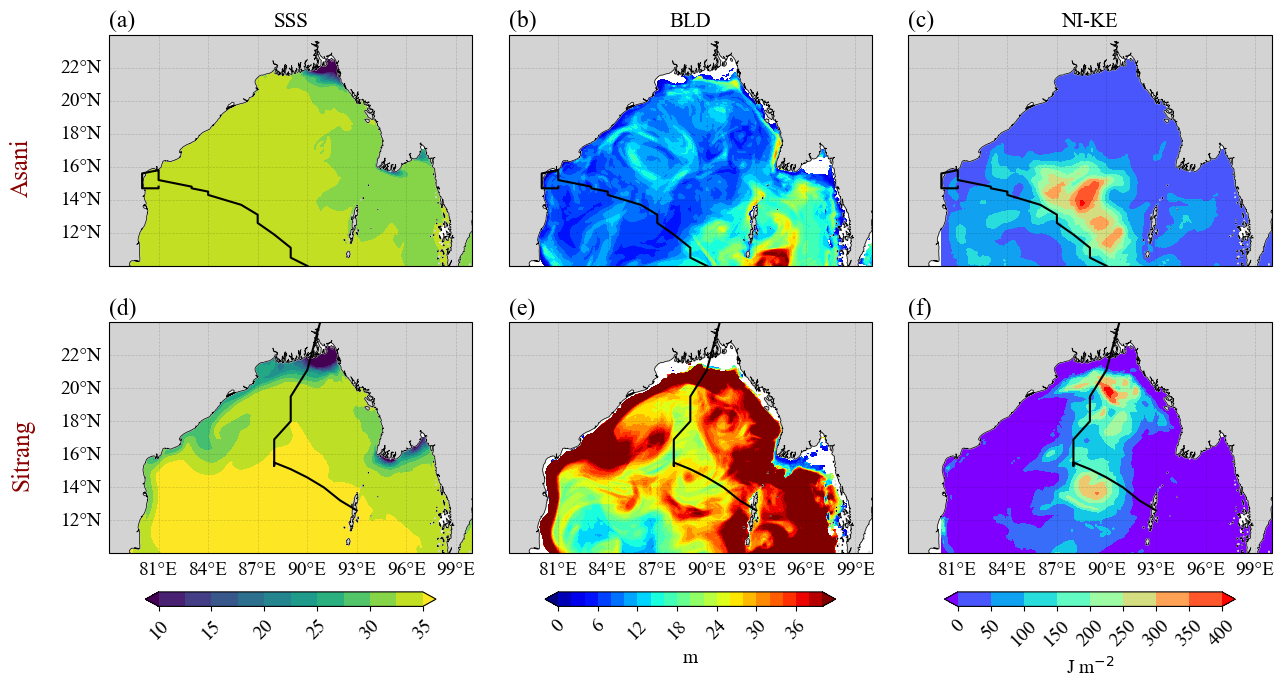

In [72]:
fig,ax = plt.subplots(2,3, figsize=(15,10), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=-0.125,wspace=0.1)
axn=ax.flat
pl1=SALT_asani.squeeze().plot.contourf(ax=axn[0],levels=np.arange(10,37.5,2.5),add_colorbar=False,extend='both')
pl2=BLD_asani.squeeze().plot.contourf(ax=axn[1],levels=np.arange(0,42,2),cmap='jet',add_colorbar=False,extend='both')
pl3=NIKE_asani.squeeze().plot.contourf(ax=axn[2],levels=np.arange(0,450,50),cmap='rainbow',add_colorbar=False,extend='both')

SALT_sitrang.squeeze().plot.contourf(ax=axn[3],levels=np.arange(10,37.5,2.5),add_colorbar=False)
BLD_sitrang.squeeze().plot.contourf(ax=axn[4],levels=np.arange(0,42,2),cmap='jet',add_colorbar=False)
NIKE_sitrang.squeeze().plot.contourf(ax=axn[5],levels=np.arange(0,450,50),cmap='rainbow',add_colorbar=False)

cbar=fig.colorbar(pl1,ax=ax[:,0],orientation='horizontal',shrink=0.8,pad=0.05)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=14,rotation=45)

cbar=fig.colorbar(pl2,ax=ax[:,1],orientation='horizontal',shrink=0.8,pad=0.05)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=14,rotation=45)
cbar.set_label('m', fontsize=14)

cbar=fig.colorbar(pl3,ax=ax[:,2],orientation='horizontal',shrink=0.8,pad=0.05)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=14,rotation=45)
cbar.set_label('J m$^{-2}$', fontsize=14)

for i in range(6):
    fig_beauty(axn[i],2,3,i,14,lc='lightgrey')
    axn[i].set_extent([78,100,10,24])
    if i < 3:
        axn[i].set_title(['SSS','BLD','NI-KE'][i],fontsize=15)
        df=pd.read_csv('../CYCLONE-NIW/bio2022/bio022022.dat',header=None)
        lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
        lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
        axn[i].plot(lon,lat,color='black',lw=1.5)
    else:
        axn[i].set_title('')
        df=pd.read_csv('../CYCLONE-NIW/bio2022/bio052022.dat',header=None)
        lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
        lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
        axn[i].plot(lon,lat,color='black',lw=1.5)
for n in range(6):
    axn[n].text(78,24.5,['(a)','(b)','(c)','(d)','(e)','(f)'][n],fontsize=17)
ax[0,0].text(72,16,'Asani',color='darkred',va='center',rotation=90,fontsize=18)
ax[1,0].text(72,16,'Sitrang',color='darkred',va='center',rotation=90,fontsize=18)
plt.savefig('FIGURE/Figure5.jpg',bbox_inches='tight',dpi=800)

## Figure 6

In [27]:
ds_300_as= ren_fun_sck('/home/sajidh/Desktop/HDD/IITM/CYCLONE_NEW/NIKE_LAYER/ASANI/NIKE/NIKE_KE_UV_342.nc').NIKE.squeeze().drop('depth')
ds_50_as= ren_fun_sck('/home/sajidh/Desktop/HDD/IITM/CYCLONE_NEW/NIKE_LAYER/ASANI/NIKE/NIKE_KE_UV_50.nc').NIKE.squeeze().drop('depth')
ratio_300_100_as=ds_300_as/ds_50_as

ds_300_sit= ren_fun_sck('/home/sajidh/Desktop/HDD/IITM/CYCLONE_NEW/NIKE_LAYER/SITRANG/NIKE/NIKE_KE_UV_342.nc').NIKE.squeeze().drop('depth')
ds_50_sit= ren_fun_sck('/home/sajidh/Desktop/HDD/IITM/CYCLONE_NEW/NIKE_LAYER/SITRANG/NIKE/NIKE_KE_UV_50.nc').NIKE.squeeze().drop('depth')
ratio_300_100_sit=ds_300_sit/ds_50_sit

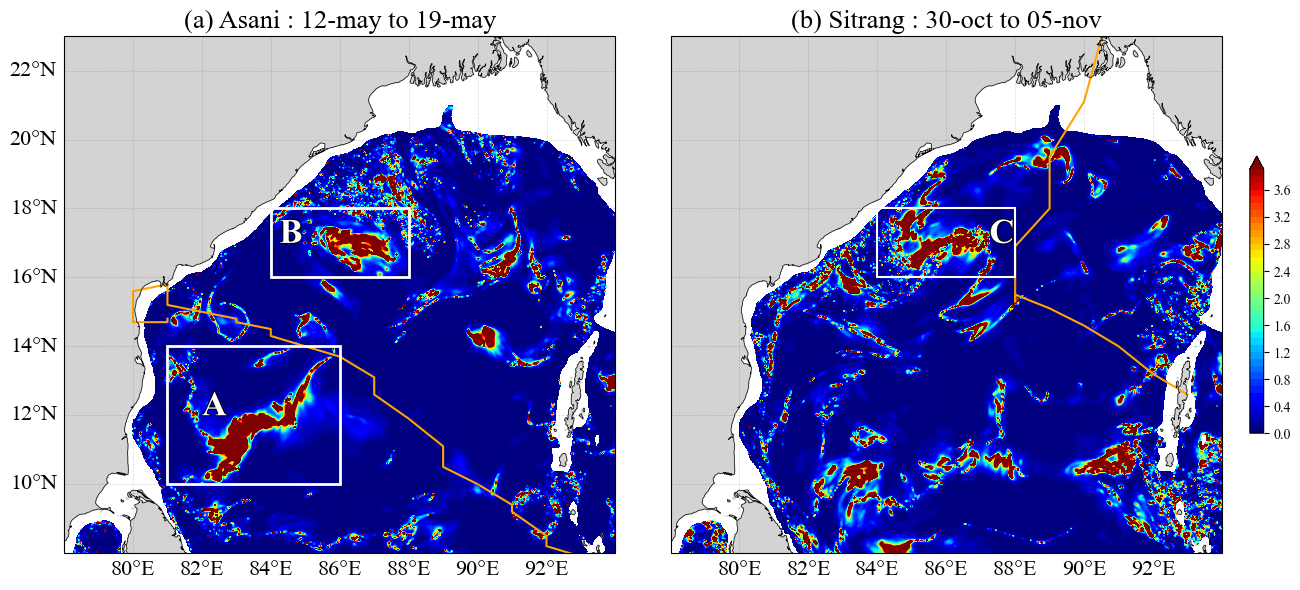

In [36]:
fig,ax = plt.subplots(1,2, figsize=(18,12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(wspace=0.1)
pl=ratio_300_100_as.sel(time=slice('12-may-2022','19-may-2022')).mean('time').plot.contourf(ax=ax[0],levels=np.arange(0,4,0.1),cmap='jet',add_colorbar=False,extend='max')
df=pd.read_csv('../CYCLONE-NIW/bio2022/bio022022.dat',header=None)
lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
ax[0].plot(lon,lat,color='orange')
ax[0].set_title('(a) Asani : 12-may to 19-may',fontsize=19)
fig_beauty(ax[0],1,2,0,16,lc='lightgrey')
ax[0].set_extent([78,94,8,23])
box_map(81,86,10,14,ax[0],c='white',lss='-',lww=2)
ax[0].text(82, 12, 'A',fontsize=25,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1.5, foreground='black'),pe.Normal()])
box_map(84,88,16,18,ax[0],c='white',lss='-',lww=2)
ax[0].text(84.25, 17, 'B',fontsize=25,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1.5, foreground='black'),pe.Normal()])

ratio_300_100_sit.sel(time=slice('30-oct-2022','05-nov-2022')).mean('time').plot.contourf(ax=ax[1],levels=np.arange(0,4,0.1),cmap='jet',add_colorbar=False)
df=pd.read_csv('../CYCLONE-NIW/bio2022/bio052022.dat',header=None)
lat=[float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon=[float(str(i)[1:4]) for i in df[7].astype('str')]
ax[1].plot(lon,lat,color='orange')
ax[1].set_title('(b) Sitrang : 30-oct to 05-nov',fontsize=19)
fig_beauty(ax[1],1,2,1,16,lc='lightgrey')
ax[1].set_extent([78,94,8,23])
box_map(84,88,16,18,ax[1],c='white',lss='-',lww=1.5)
ax[1].text(87.25, 17, 'C',fontsize=25,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1.5, foreground='black'),pe.Normal()])

cbar=fig.colorbar(pl,ax=ax[:],shrink=0.3,pad=0.02)
cbar.ax.minorticks_off()
plt.savefig('FIGURE/Figure6.jpg',bbox_inches='tight',dpi=800)

IndexError: index 228 is out of bounds for axis 0 with size 228

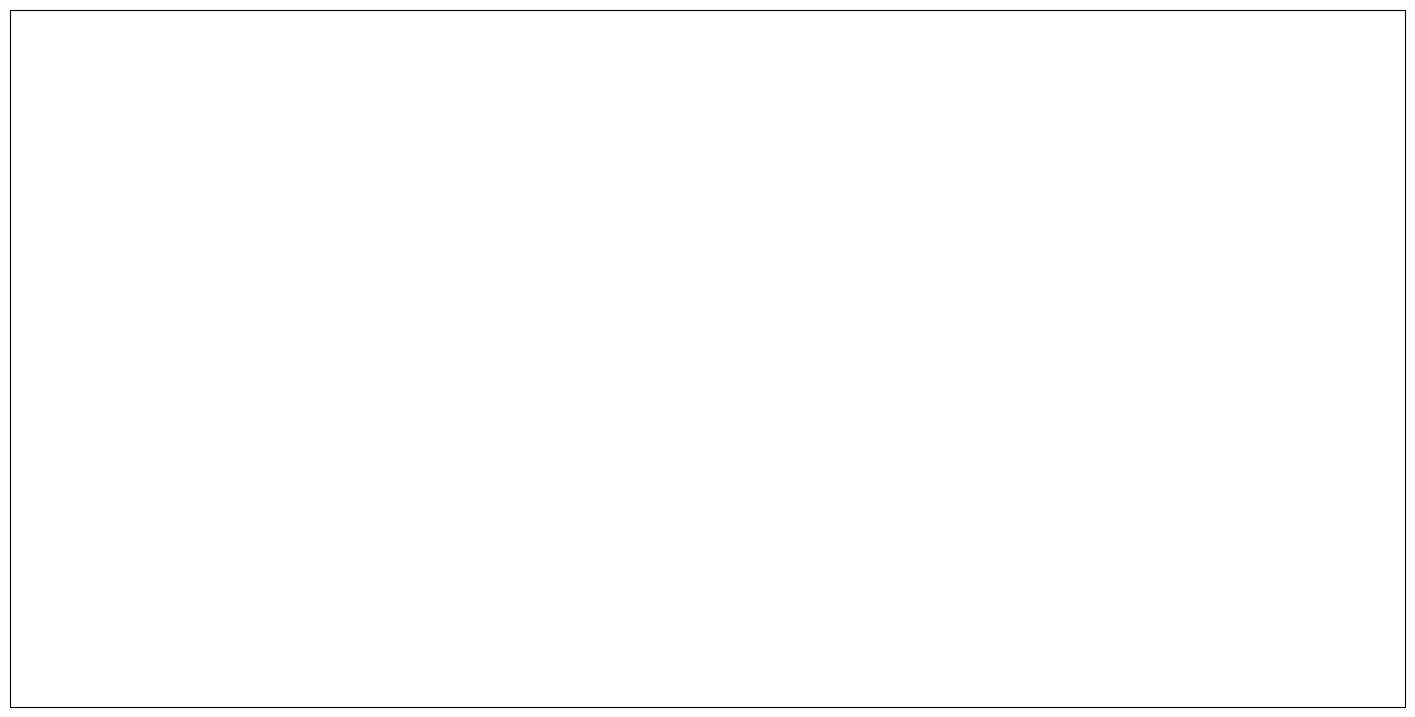

In [114]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd

# make output folder
os.makedirs('anims', exist_ok=True)

# read cyclone track once
df = pd.read_csv('../CYCLONE-NIW/bio2022/bio022022.dat', header=None)
lat = [float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon = [float(str(i)[1:4]) for i in df[7].astype('str')]

for t in range(300):

    fig, ax = plt.subplots(1, figsize=(18,12),
                           subplot_kw={'projection': ccrs.PlateCarree()})

    # plot data
    pl = ratio_300_100_as.isel(time=t).plot.contourf(
        ax=ax,
        levels=np.arange(0,4,0.1),
        cmap='jet',
        add_colorbar=False,
        extend='max'
    )

    # track
    ax.plot(lon, lat, color='orange')

    # styling
    fig_beauty(ax,1,2,0,16,lc='lightgrey')
    ax.set_extent([78,94,8,23])

    box_map(81,86,10,14,ax,c='white',lss='--',lww=1.5)
    box_map(84,88,16,18,ax,c='white',lss='--',lww=1.5)
    cbar=fig.colorbar(pl,ax=ax,shrink=0.3,pad=0.02)
    cbar.ax.minorticks_off()

    # save frame
    plt.savefig(f'anims/{t:03d}.jpg', dpi=150, bbox_inches='tight')
    plt.close(fig)

## Figure S6

In [98]:
from matplotlib.colors import PowerNorm

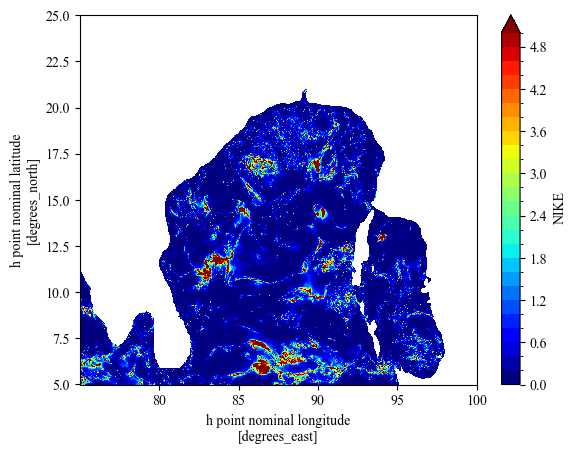

In [107]:
ratio_300_100_as.sel(time=slice('06-may-2022','28-may-2022')).mean('time').plot(levels=np.arange(0,5.2,0.2),cmap='jet')

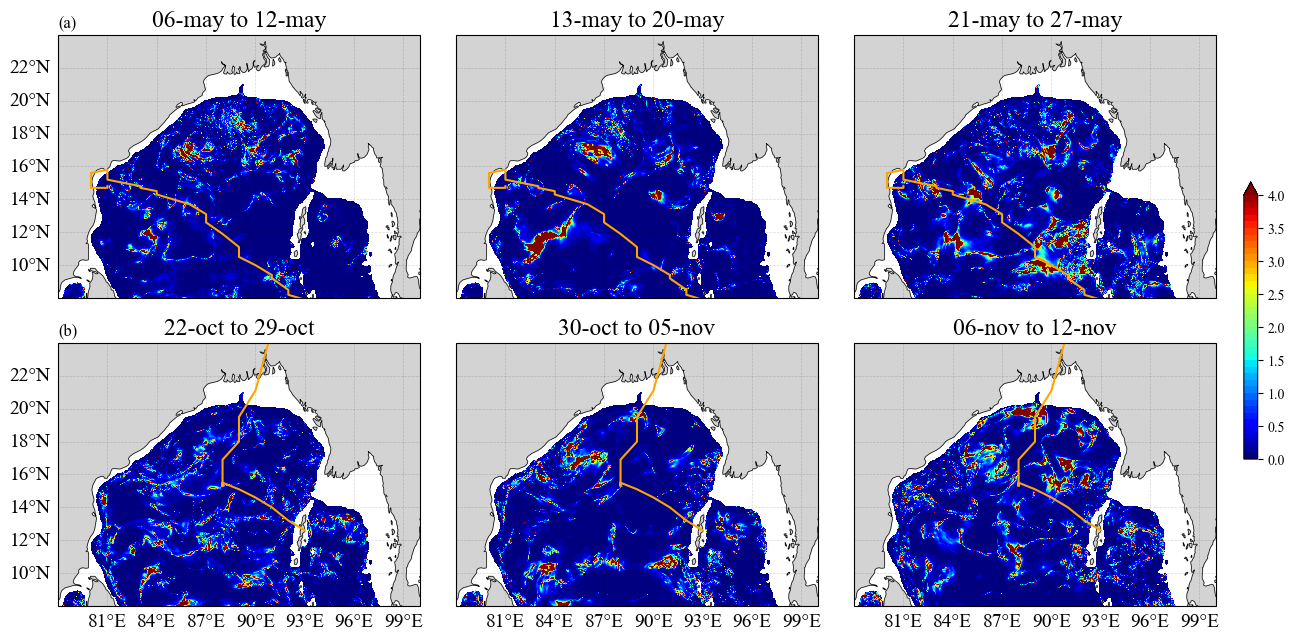

In [10]:
fig,ax = plt.subplots(2,3, figsize=(18,12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=-0.5,wspace=0.1)
axn=ax.flat

datas=[
ratio_300_100_as.sel(time=slice('06-may-2022','12-may-2022')).mean('time'),
ratio_300_100_as.sel(time=slice('12-may-2022','19-may-2022')).mean('time'),
ratio_300_100_as.sel(time=slice('20-may-2022','28-may-2022')).mean('time'),
ratio_300_100_sit.sel(time=slice('21-oct-2022','29-oct-2022')).mean('time'),
ratio_300_100_sit.sel(time=slice('30-oct-2022','05-nov-2022')).mean('time'),
ratio_300_100_sit.sel(time=slice('06-nov-2022','12-nov-2022')).mean('time')
]

for i in range(6):
    pl=(datas[i]).plot(levels=np.arange(0,4.1,0.1),cmap='jet',ax=axn[i],add_colorbar=False)
    fig_beauty(axn[i],2,3,i,14,lc='lightgrey')
    axn[i].set_extent([78,100,8,24])

    if i<3:
        df=pd.read_csv('../CYCLONE-NIW/bio2022/bio022022.dat',header=None)
    else:
        df=pd.read_csv('../CYCLONE-NIW/bio2022/bio052022.dat',header=None)

    lat=[float(str(j)[1:4])/10 for j in df[6].astype('str')]
    lon=[float(str(j)[1:4]) for j in df[7].astype('str')]
    axn[i].plot(lon,lat,color='orange',lw=1.5)

    axn[i].set_title(['06-may to 12-may','13-may to 20-may','21-may to 27-may',
                      '22-oct to 29-oct','30-oct to 05-nov','06-nov to 12-nov'][i],fontsize=17)

for n in range(6):
    axn[n].set_title(['(a)','','','(b)','',''][n],loc='left')

cbar=fig.colorbar(pl,ax=ax[:],shrink=0.3,pad=0.02)
cbar.ax.minorticks_off()
plt.savefig('FIGURE/S6.jpg',bbox_inches='tight',dpi=800)

## Sx

In [14]:
ds_asa=ren_fun_sck('eke_box/asani_box/asani_point_vel_total_boxh.nc')
ds_sit=ren_fun_sck('eke_box/sitrang_box/sitrang_point_vel_total_boxf.nc')
uvel_i_asa,vvel_i_asa=inertial_filter(ds_asa.UTOP,ds_asa.VTOP,12)
eke_asa=0.5*1024*(uvel_i_asa**2 + vvel_i_asa**2)

uvel_i_sit,vvel_i_sit=inertial_filter(ds_sit.UTOP,ds_sit.VTOP,17)
eke_sit=0.5*1024*(uvel_i_sit**2 + vvel_i_sit**2)

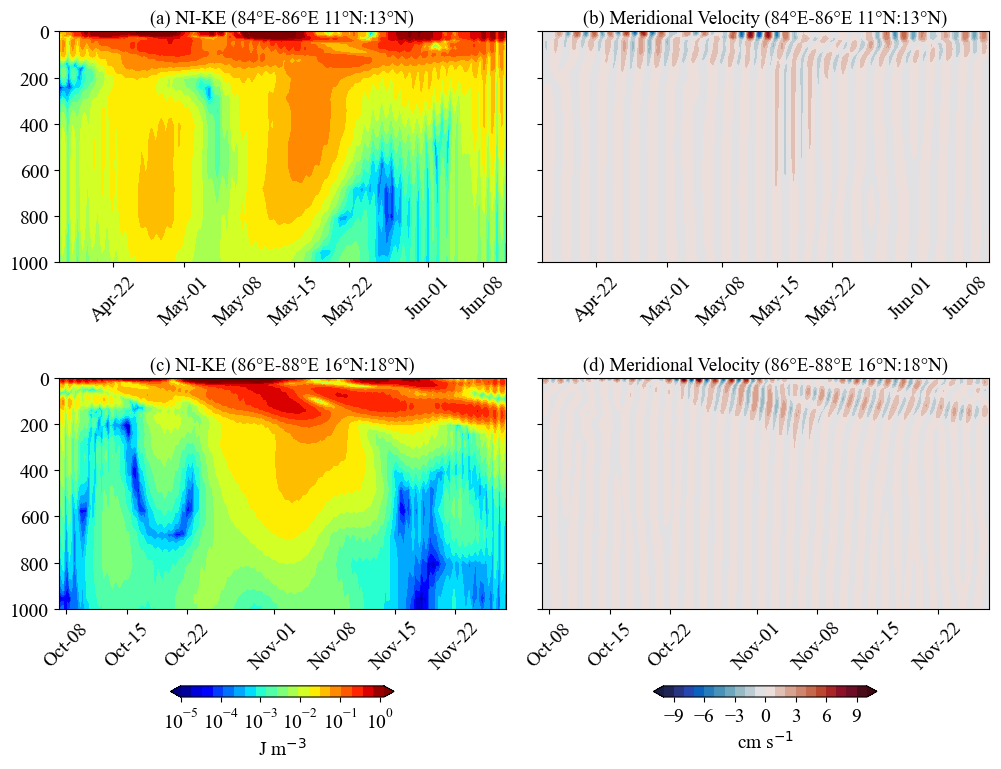

In [38]:
plt.rcParams['font.size']=14
import matplotlib.dates as mdates
date_form = mdates.DateFormatter('%b-%d') 

fig,ax = plt.subplots(2,2,figsize=(12,10),sharey=True)
fig.subplots_adjust(wspace=0.08,hspace=0.5)
axn=ax.flat
levels = np.logspace(-5, 0.1, 20)
pl1=axn[0].contourf(eke_asa.time, eke_asa.depth, eke_asa.data.T,levels=levels, norm=plt.matplotlib.colors.LogNorm(),extend='both',cmap='jet')
axn[0].tick_params(axis='x',rotation=45)
ticks = [1e-2,1e-1,1,1e1,1e2]


pl2=axn[1].contourf(vvel_i_asa.time, vvel_i_asa.depth, vvel_i_asa.data.T*100,levels=np.arange(-10,11,1),extend='both',cmap='cmo.balance')
axn[1].tick_params(axis='x',rotation=45)

pl3=axn[2].contourf(eke_sit.time, eke_sit.depth, eke_sit.data.T,levels=levels, norm=plt.matplotlib.colors.LogNorm(),extend='both',cmap='jet')
axn[2].tick_params(axis='x',rotation=45)
ticks = [1e-2,1e-1,1,1e1,1e2]


pl4=axn[3].contourf(vvel_i_sit.time, vvel_i_sit.depth, vvel_i_sit.data.T*100,levels=np.arange(-10,11,1),extend='both',cmap='cmo.balance')
axn[3].tick_params(axis='x',rotation=45)

axn[3].set_ylim(1000,0)

titl=['(a) NI-KE (84°E-86°E 11°N:13°N)','(b) Meridional Velocity (84°E-86°E 11°N:13°N)','(c) NI-KE (86°E-88°E 16°N:18°N)','(d) Meridional Velocity (86°E-88°E 16°N:18°N)']
for n,a in enumerate(axn):
    a.xaxis.set_major_formatter(date_form)
    a.tick_params(axis='x', rotation=45)
    a.set_title(titl[n],fontsize=13.5)

cbar=fig.colorbar(pl1,ax=ax[:,0],orientation='horizontal',shrink=0.5,ticks=[1e-5,1e-4,1e-3,1e-2,1e-1,1e0],pad=0.1)
cbar.ax.minorticks_off()
cbar.set_label('J m$^{-3}$', fontsize=14)


cbar=fig.colorbar(pl4,ax=ax[:,1],orientation='horizontal',shrink=0.5,pad=0.1)
cbar.ax.minorticks_off()
cbar.set_label('cm s$^{-1}$', fontsize=14)
plt.savefig('FIGURE/S7.jpg',bbox_inches='tight',dpi=800)

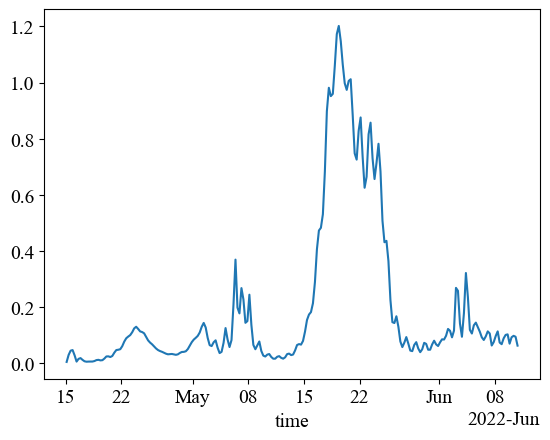

In [35]:
(eke_asa.sel(depth=slice(150,300)).mean('depth')/eke_asa.sel(depth=slice(0,125)).mean('depth')).plot()

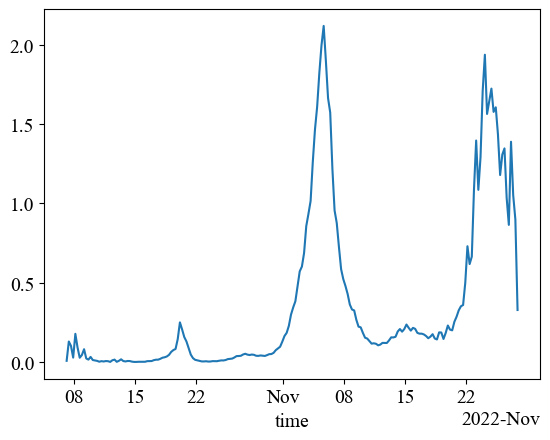

In [37]:
(eke_sit.sel(depth=slice(150,300)).mean('depth')/eke_sit.sel(depth=slice(0,125)).mean('depth')).plot()

## Figure 7

In [4]:
# ---- parent directory containing all folders ----
base_dir = "JPDF/ASANI/"

# ---- get all subfolders ----
folders = sorted([f for f in glob.glob(os.path.join(base_dir, "*")) if os.path.isdir(f)])


all_data = []
data_dict = {}

# ---- first pass: load data + collect for common color scale ----
for f in folders:
    file = glob.glob(os.path.join(f, "*.nc"))[0]
    ds = xr.open_dataset(file)

    var = ds[list(ds.data_vars)[1:3]]  # first variable
    data_dict[f] = var
    all_data.append(var)

In [5]:
merge_dats_utop=[]
for i in range(11):
    print(i)
    data_cyc=all_data[i]
    lat1,lat2=data_cyc.UTOP.attrs['long_name'].split('Y')[1].split('=')[1].split('@')[0].split(':')
    lat1,lat2=int(lat1),int(lat2)
    
    lon1,lon2=data_cyc.UTOP.attrs['long_name'].split('Y')[0].split('=')[1].split('@')[0].split(':')
    lon1,lon2=int(lon1),int(lon2)
    data_cyc=data_cyc.assign_coords({'lat':(lat1+lat2)/2, 'lon':(lon1+lon2)/2}).expand_dims(['lat','lon'])
    merge_dats_utop.append(data_cyc)
data=xr.merge(merge_dats_utop)

0
1
2
3
4
5
6
7
8
9
10


In [6]:
def inertial_period(lat_deg):
    Omega=7.2921e-5
    lat_rad = np.deg2rad(lat_deg)
    f = 2 * Omega * np.sin(lat_rad)
    T = 2 * np.pi / f
    return 1/(T / 3600) 

0
1
2
3
4
5
6
7
8
9
10
11


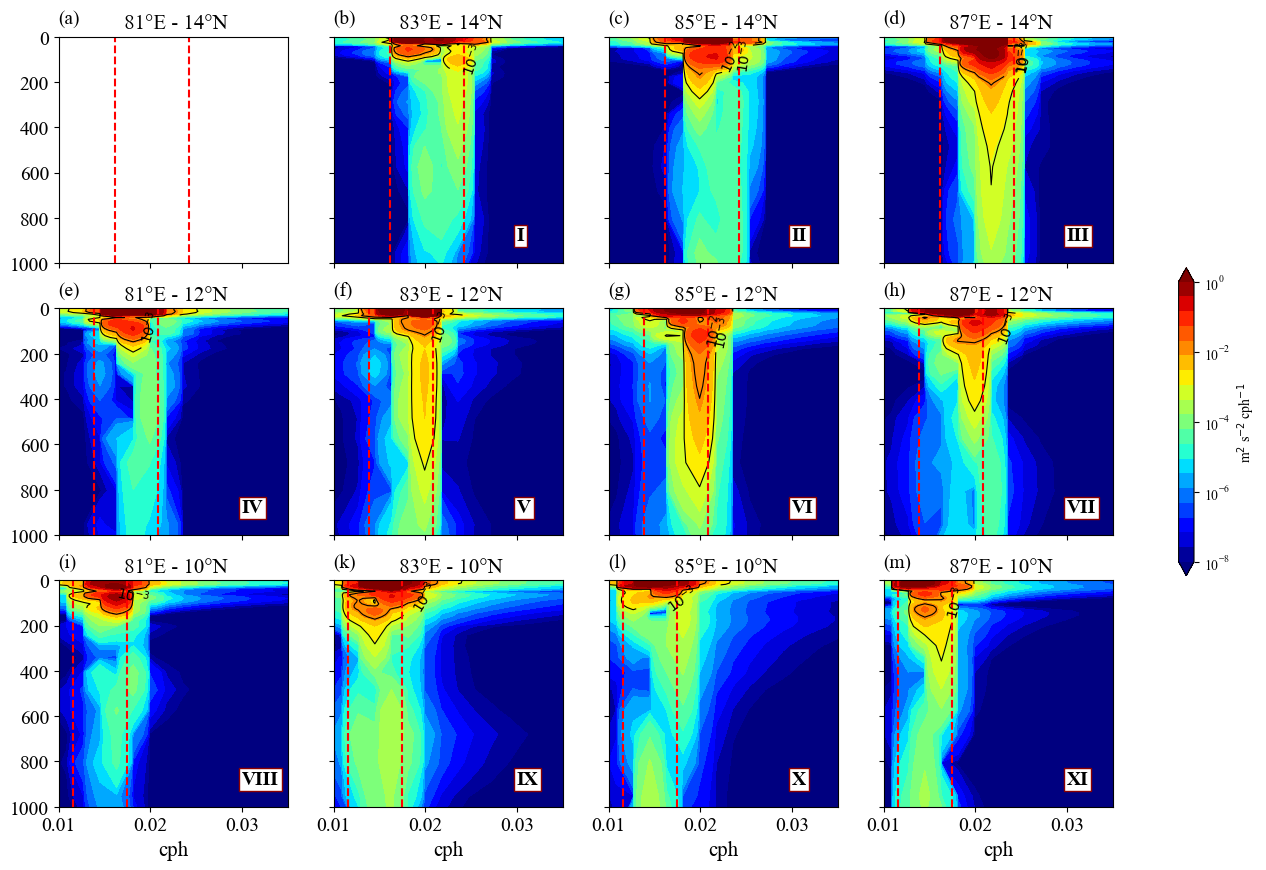

In [32]:
fig, ax = plt.subplots(3, 4, figsize=(17, 10),sharex=True,sharey=True)
axb = ax[::-1]  # south at bottom

lats = data.lat.values
lons = data.lon.values
l=0
num_list=['','(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(k)','(l)']
for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):

        varn = data.sel(lat=lat, lon=lon)

        ds_uvel = varn.UTOP
        ds_vvel = varn.VTOP

        ds_uvel, ds_vvel = inertial_filter(ds_uvel, ds_vvel, varn.lat)

        CW = []
        CCW = []

        for k in range(41):
            xx, yy, cw, ccw, F = spec_rot(
                ds_uvel.isel(depth=k).sel(time=slice('06-may-2022','28-may-2022')),
                ds_vvel.isel(depth=k).sel(time=slice('06-may-2022','28-may-2022'))
            )

            pos = F > 0
            fq = F[pos]
            cw = cw[pos]
            ccw = ccw[pos]

            CW.append(cw)
            CCW.append(ccw)

        CW_spectrum_sit = xr.DataArray(CW, coords={'depth': ds_uvel.depth, 'F': fq})

        E_cw = np.abs(CW_spectrum_sit)**2

        freq = CW_spectrum_sit['F'].values
        depth = CW_spectrum_sit['depth'].values

        # ---- plot ----
        cf = axb[i, j].contourf(
            freq, depth, E_cw,
            levels=np.logspace(-8, 0, 20),
            norm=plt.matplotlib.colors.LogNorm(),
            cmap='jet',
            extend='both'
        )
        cfn = axb[i, j].contour(
        freq, depth, E_cw,
        levels=[0.001, 0.01],
        norm=plt.matplotlib.colors.LogNorm(),
        colors='black',
        linewidths=0.8
        )
        axb[i,j].clabel(cfn, fmt=lambda x: rf'$10^{{{int(np.log10(x))}}}$',fontsize=10)
        
        axb[i, j].set_ylim(1000, 0)
        axb[i, j].set_title(num_list[l]+' '+f"{lon:.0f}°E - {lat:.0f}°N",fontsize=15)
        a,b=inertial_period(lat)*0.8,inertial_period(lat)*1.2
        axb[i,j].axvline(a,color='red',lw=1.5,ls='--')
        axb[i,j].axvline(b,color='red',lw=1.5,ls='--')
        

# ---- remove empty subplot (since you have 11 panels) ----
if len(lats) * len(lons) > len(data.lat) * len(data.lon):
    axb[-1, -1].set_visible(False)


text_tit=['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(k)','(l)','(m)']
num=['','I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII']

# ---- colorbar ----
cbar=fig.colorbar(cf, ax=axb[:,:], ticks=[1e-8,1e-6,1e-4,1e-2,1e0,1e2],shrink=0.4,pad=0.05)
axn=ax.flat
cbar.set_label(r'm$^2$ s$^{-2}$ cph$^{-1}$')
for n in range(12) :
    print(n)
    axn[n].text(0.01,-60,text_tit[n],fontsize=14)
    axn[n].text(0.03,900,num[n],fontsize=14,fontweight='bold',bbox=dict(facecolor='white', edgecolor='darkred', pad=2))
    axn[n].set_xlim(0.01,0.035)
    axn[n].tick_params(axis='both',labelsize=14)
    if n >7:
        axn[n].set_xlabel('cph',fontsize=15)
plt.savefig('Figure7_1.pdf',bbox_inches='tight')

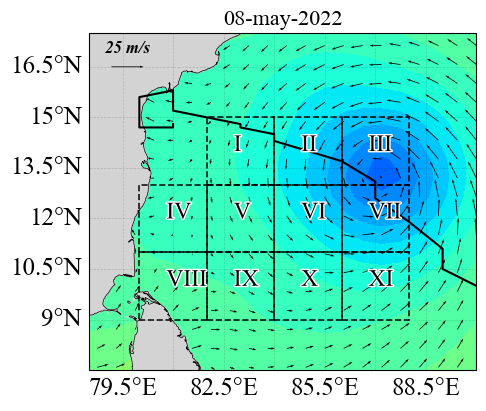

In [22]:
ds_u10=ren_fun_sck('/mnt/HDD/IITM/CYCLONE-NIW/Data/jra_u10.nc')
ds_v10=ren_fun_sck('/mnt/HDD/IITM/CYCLONE-NIW/Data/jra_v10.nc')
ds_psl=ren_fun_sck('/mnt/HDD/IITM/CYCLONE-NIW/Data/psl.nc')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---- your box function ----
import matplotlib.patches as patches
def box_map(l1, l2, la1, la2, ax, lww=1.5, lss='-', c='black', al=1):
    rect = patches.Rectangle((l1, la1), l2-l1, la2-la1,
                             lw=lww, ls=lss,
                             edgecolor=c, facecolor='none',
                             zorder=3, alpha=al)
    ax.add_patch(rect)

# ---- data selection ----
u_aug = ds_u10.u10.sel(time=slice('05-may-2022','26-may-2022')).sel(lon=slice(78,100), lat=slice(5,25))
v_aug = ds_v10.v10.sel(time=slice('05-may-2022','26-may-2022')).sel(lon=slice(78,100), lat=slice(5,25))
psl_aug = ds_psl.psl.sel(time=slice('05-may-2022','26-may-2022')).sel(lon=slice(78,100), lat=slice(5,25))

# ---- cyclone track ----
df = pd.read_csv('/mnt/HDD/IITM/CYCLONE-NIW/bio2022/bio022022.dat', header=None)
lat_track = [float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon_track = [float(str(i)[1:4]) for i in df[7].astype('str')]

# ---- plot ----
fig,axn = plt.subplots(1, figsize=(5,5), subplot_kw={'projection': ccrs.PlateCarree()})
plt.rcParams.update({
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal'})

i = 30  # choose time index

# pressure
pl = (psl_aug.isel(time=i)/100).plot.contourf(
    levels=np.arange(990,1021,1),
    cmap='jet',
    add_colorbar=False,
    extend='both',
    ax=axn
)

# wind vectors
qn = quiver_pl(axn,
               u_aug.isel(time=i),
               v_aug.isel(time=i),
               sl=300)

axn.quiverkey(qn, 0.1, 0.9, 25, '25 m/s',
              zorder=5,
              fontproperties={'size':12,'style':'oblique','weight':'bold'})


# ---- DRAW ALL BOXES (this is what you wanted) ----
k=0
for lat in data.lat.values:
    for lon in data.lon.values:
        if not (lon == 81.0 and lat == 14.0):
            box_map(lon-1, lon+1, lat-1, lat+1,
                    axn,
                    lww=1.2,
                    c='black',
                    lss='--',
                    al=0.9)
# ---- formatting ----
fig_beauty(axn, 1, 1, 0, 18, lc='lightgrey')

lonn=[83,85,87,81,83,85,87,81,83,85,87]
latt=[14,14,14,12,12,12,12,10,10,10,10]
text_tit=['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(k)','(l)']
num = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII']
for i in range(11):
    axn.text(lonn[i]-0.2, latt[i], num[i], fontsize=17, color='black', path_effects=[pe.withStroke(linewidth=2, foreground='white')])

# cyclone track
axn.plot(lon_track, lat_track, lw=1.5, color='black')
axn.set_extent([78.5,90,7.5,17.5])
# ---- save ----
#fname = f'asani_box_{name}.jpg'
plt.title('08-may-2022',fontsize=16)
plt.savefig('Figure_7_2.pdf', bbox_inches='tight')

## Figure 8

In [33]:
import os
import glob
import xarray as xr

# ---- your folder ----
base_dir = "JPDF/SITRANG/folder/"

# ---- get all .nc files ----
files = sorted(glob.glob(os.path.join(base_dir, "*.nc")))

all_data = []
data_dict = {}

# ---- loop over files ----
for file in files:
    ds = xr.open_dataset(file)

    var = ds[list(ds.data_vars)[1:3]]  # adjust if needed
    data_dict[file] = var
    all_data.append(var)

In [34]:
merge_dats_utop=[]
for i in range(12):
    print(i)
    data_cyc=all_data[i]
    lat1,lat2=data_cyc.UTOP.attrs['long_name'].split('Y')[1].split('=')[1].split('@')[0].split(':')
    lat1,lat2=int(lat1),int(lat2)
    
    lon1,lon2=data_cyc.UTOP.attrs['long_name'].split('Y')[0].split('=')[1].split('@')[0].split(':')
    lon1,lon2=int(lon1),int(lon2)
    data_cyc=data_cyc.assign_coords({'lat':(lat1+lat2)/2, 'lon':(lon1+lon2)/2}).expand_dims(['lat','lon'])
    merge_dats_utop.append(data_cyc)
data=xr.merge(merge_dats_utop)

0
1
2
3
4
5
6
7
8
9
10
11


0
1
2
3
4
5
6
7
8
9
10
11


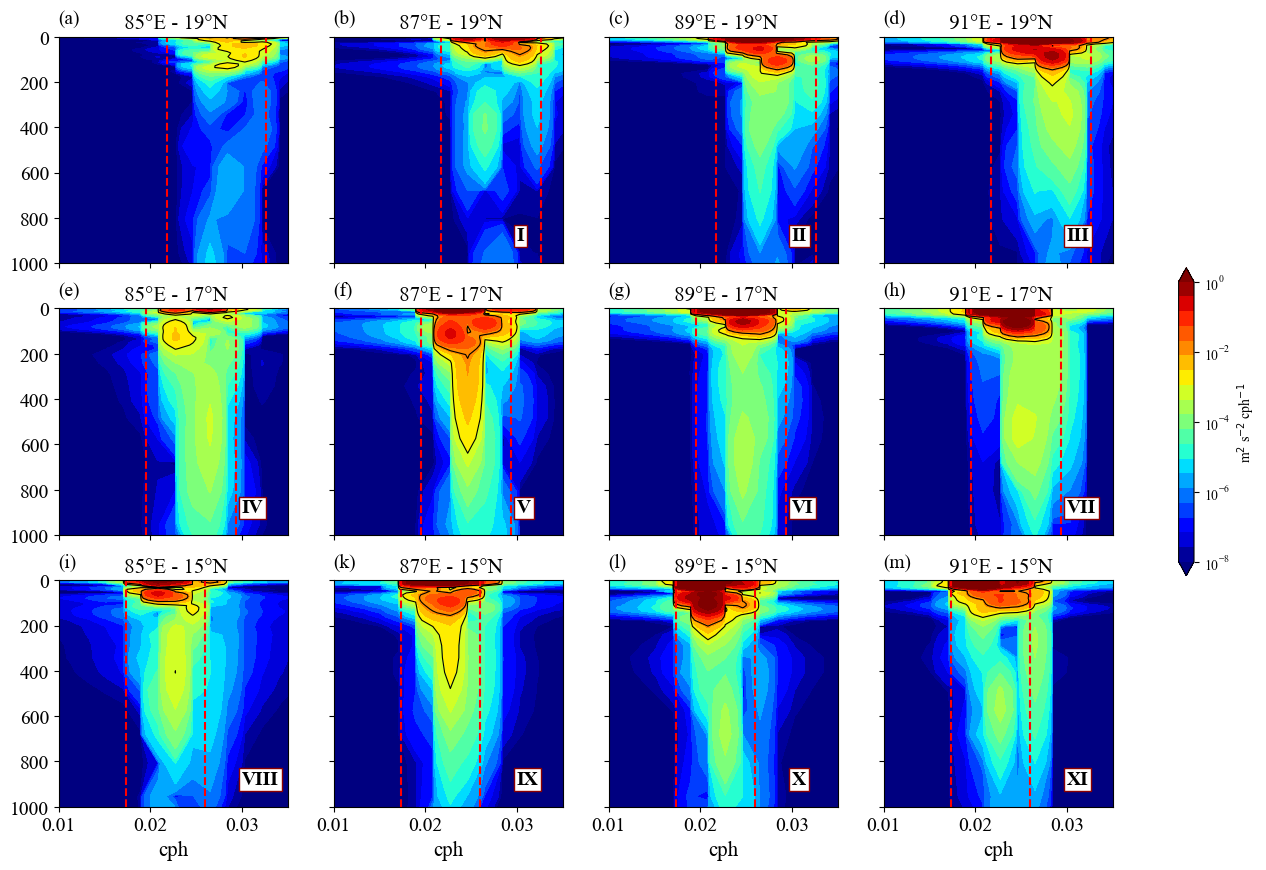

In [36]:
fig, ax = plt.subplots(3, 4, figsize=(17, 10),sharex=True,sharey=True)
axb = ax[::-1]  # south at bottom

lats = data.lat.values
lons = data.lon.values
l=0
num_list=['','(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(k)','(l)']

for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):

        varn = data.sel(lat=lat, lon=lon)

        ds_uvel = varn.UTOP
        ds_vvel = varn.VTOP

        ds_uvel, ds_vvel = inertial_filter(ds_uvel, ds_vvel, varn.lat)

        CW = []
        CCW = []

        for k in range(41):
            xx, yy, cw, ccw, F = spec_rot(
                ds_uvel.isel(depth=k).sel(time=slice('22-oct-2022','12-nov-2022')),
                ds_vvel.isel(depth=k).sel(time=slice('22-oct-2022','12-nov-2022'))
            )

            pos = F > 0
            fq = F[pos]
            cw = cw[pos]
            ccw = ccw[pos]

            CW.append(cw)
            CCW.append(ccw)

        CW_spectrum_sit = xr.DataArray(CW, coords={'depth': ds_uvel.depth, 'F': fq})

        E_cw = np.abs(CW_spectrum_sit)**2

        freq = CW_spectrum_sit['F'].values
        depth = CW_spectrum_sit['depth'].values

        # ---- plot ----
        cf = axb[i, j].contourf(
            freq, depth, E_cw,
            levels=np.logspace(-8, 0, 20),
            norm=plt.matplotlib.colors.LogNorm(),
            cmap='jet',
            extend='both'
        )
        cfn = axb[i, j].contour(
        freq, depth, E_cw,
        levels=[0.001, 0.01],
        norm=plt.matplotlib.colors.LogNorm(),
        colors='black',
        linewidths=0.8
        )
        
        axb[i, j].set_ylim(1000, 0)
        axb[i, j].set_xlim(0.01, 0.05)
        axb[i, j].set_title(num_list[l]+' '+f"{lon:.0f}°E - {lat:.0f}°N",fontsize=15)
        a,b=inertial_period(lat)*0.8,inertial_period(lat)*1.2
        axb[i,j].axvline(a,color='red',lw=1.5,ls='--')
        axb[i,j].axvline(b,color='red',lw=1.5,ls='--')
        

# ---- remove empty subplot (since you have 11 panels) ----



text_tit=['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(k)','(l)','(m)']
num = ['','I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII']

# ---- colorbar ----
cbar=fig.colorbar(cf, ax=axb[:,:], ticks=[1e-8,1e-6,1e-4,1e-2,1e0,1e2],shrink=0.4,pad=0.05)
axn=ax.flat
cbar.set_label(r'm$^2$ s$^{-2}$ cph$^{-1}$')
for n in range(12) :
    print(n)
    axn[n].text(0.01,-60,text_tit[n],fontsize=14)
    axn[n].text(0.03,900,num[n],fontsize=14,fontweight='bold',bbox=dict(facecolor='white', edgecolor='darkred', pad=2))
    axn[n].set_xlim(0.01,0.035)
    axn[n].tick_params(axis='both',labelsize=14)
    if n >7:
        axn[n].set_xlabel('cph',fontsize=15)
plt.savefig('Figure_8_1.pdf',bbox_inches='tight')

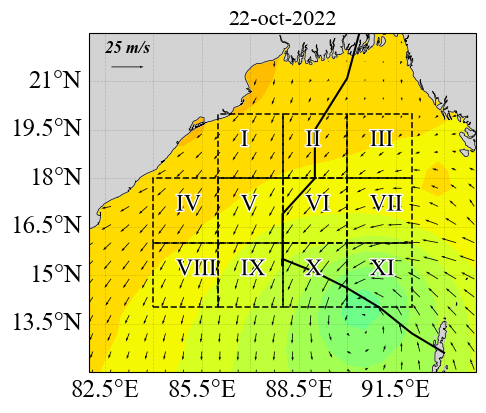

In [40]:
ds_u10=ren_fun_sck('/mnt/HDD/IITM/CYCLONE-NIW/Data/jra_u10.nc')
ds_v10=ren_fun_sck('/mnt/HDD/IITM/CYCLONE-NIW/Data/jra_v10.nc')
ds_psl=ren_fun_sck('/mnt/HDD/IITM/CYCLONE-NIW/Data/psl.nc')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---- your box function ----
import matplotlib.patches as patches
def box_map(l1, l2, la1, la2, ax, lww=1.5, lss='-', c='black', al=1):
    rect = patches.Rectangle((l1, la1), l2-l1, la2-la1,
                             lw=lww, ls=lss,
                             edgecolor=c, facecolor='none',
                             zorder=3, alpha=al)
    ax.add_patch(rect)

# ---- data selection ----
u_aug = ds_u10.u10.sel(time=slice('20-oct-2022','26-oct-2022')).sel(lon=slice(78,100), lat=slice(5,25))
v_aug = ds_v10.v10.sel(time=slice('20-oct-2022','26-oct-2022')).sel(lon=slice(78,100), lat=slice(5,25))
psl_aug = ds_psl.psl.sel(time=slice('20-oct-2022','26-oct-2022')).sel(lon=slice(78,100), lat=slice(5,25))

# ---- cyclone track ----
df = pd.read_csv('/mnt/HDD/IITM/CYCLONE-NIW/bio2022/bio052022.dat', header=None)
lat_track = [float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon_track = [float(str(i)[1:4]) for i in df[7].astype('str')]

# ---- plot ----
fig,axn = plt.subplots(1, figsize=(5,5), subplot_kw={'projection': ccrs.PlateCarree()})
plt.rcParams.update({
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal'})

i = 20  # choose time index

# pressure
pl = (psl_aug.isel(time=i)/100).plot.contourf(
    levels=np.arange(990,1021,1),
    cmap='jet',
    add_colorbar=False,
    extend='both',
    ax=axn
)

# wind vectors
qn = quiver_pl(axn,
               u_aug.isel(time=i),
               v_aug.isel(time=i),
               sl=300)

axn.quiverkey(qn, 0.1, 0.9, 25, '25 m/s',
              zorder=5,
              fontproperties={'size':12,'style':'oblique','weight':'bold'})


# ---- DRAW ALL BOXES (this is what you wanted) ----
k=0
for lat in data.lat.values:
    for lon in data.lon.values:
        if not (lon == 85.0 and lat == 19.0):
            box_map(lon-1, lon+1, lat-1, lat+1,
                    axn,
                    lww=1.2,
                    c='black',
                    lss='--',
                    al=0.9)
# ---- formatting ----
fig_beauty(axn, 1, 1, 0, 18, lc='lightgrey')

lonn=[83,85,87,81,83,85,87,81,83,85,87]
latt=[14,14,14,12,12,12,12,10,10,10,10]
text_tit=['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(k)','(l)']

num = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII']
for i in range(11):
    axn.text(lonn[i]+3.7, latt[i]+5, num[i], fontsize=17, color='black', path_effects=[pe.withStroke(linewidth=2, foreground='white')])
# cyclone track
axn.plot(lon_track, lat_track, lw=1.5, color='black')
axn.set_extent([82,94,12,22.5])
# ---- save ----
#fname = f'asani_box_{name}.jpg'
plt.title('22-oct-2022',fontsize=16)
plt.savefig('Figure_8_2.pdf', bbox_inches='tight')

## Figure 9

In [58]:
EKE_asani_50=ren_fun_sck('NIKE_LARGE_REGION/ASANI/EKE_UV_50.nc').NIKE.sel(time=slice('06-may-2022','28-may-2022')).mean('time').squeeze()
EKE_asani_100=ren_fun_sck('NIKE_LARGE_REGION/ASANI/EKE_UV_104.nc').NIKE.sel(time=slice('06-may-2022','28-may-2022')).mean('time').squeeze()
EKE_asani_300=ren_fun_sck('NIKE_LARGE_REGION/ASANI/EKE_UV_342.nc').NIKE.sel(time=slice('06-may-2022','28-may-2022')).mean('time').squeeze()

VORT_asani_50=ren_fun_sck('VORT_LARGE_REGION/ASANI/asani_50_vort.nc').VORT_50.sel(time=slice('06-may-2022','28-may-2022')).mean('time').squeeze()
VORT_asani_100=ren_fun_sck('VORT_LARGE_REGION/ASANI/asani_104_vort.nc').VORT_104.sel(time=slice('06-may-2022','28-may-2022')).mean('time').squeeze()
VORT_asani_300=ren_fun_sck('VORT_LARGE_REGION/ASANI/asani_342_vort.nc').VORT_342.sel(time=slice('06-may-2022','28-may-2022')).mean('time').squeeze()

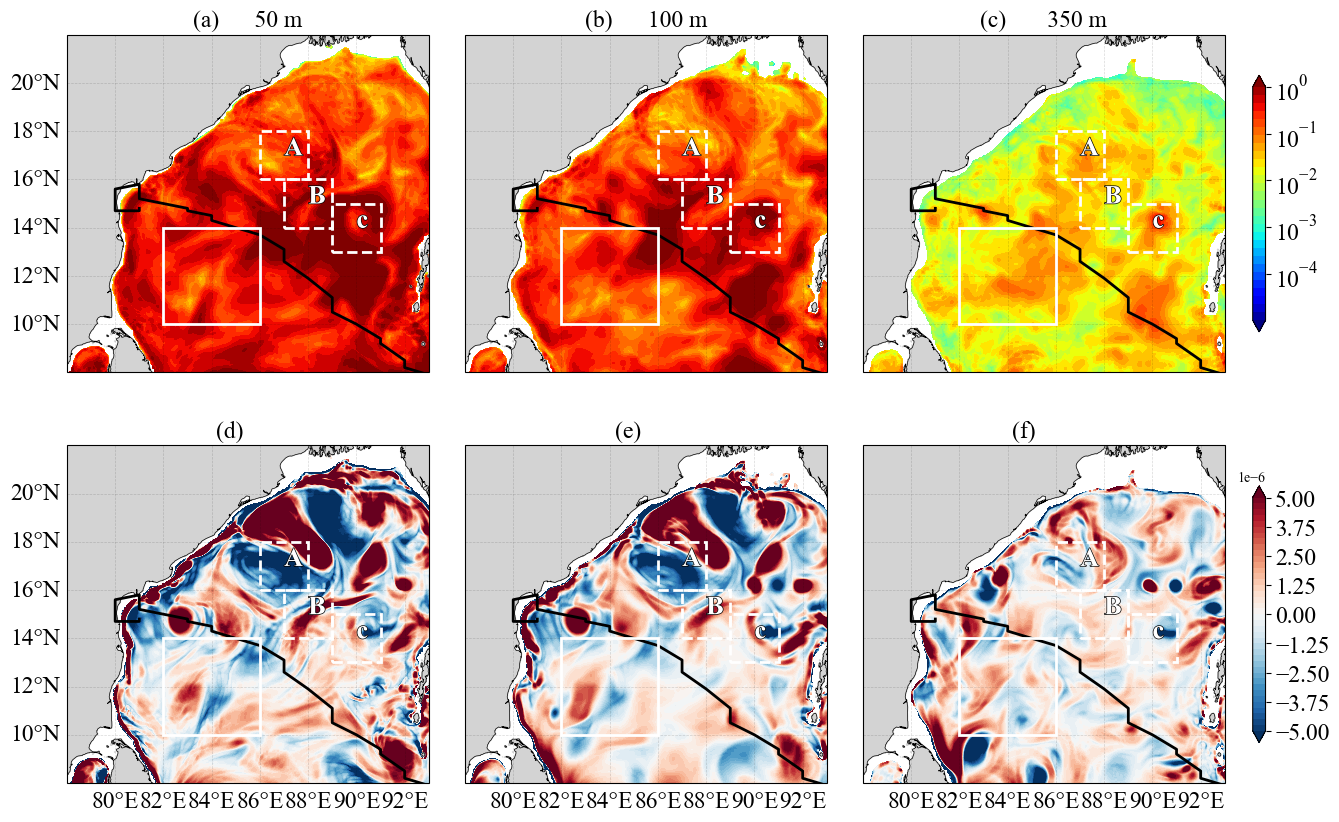

In [71]:
fig,ax = plt.subplots(2,3, figsize=(18,12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=-0.2,wspace=0.1)
axn=ax.flat

vmin = 1e-5
vmax = 1e0
lev = np.logspace(-5, 0, 30)
norm = plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
pl=EKE_asani_50.plot.contourf(ax=axn[0],add_colorbar=False,levels=lev, norm=norm,cmap='jet',extend='both')
EKE_asani_100.plot.contourf(ax=axn[1],add_colorbar=False,levels=lev, norm=norm,cmap='jet',extend='both')
EKE_asani_300.plot.contourf(ax=axn[2],add_colorbar=False,levels=lev, norm=norm,cmap='jet',extend='both')
cbar=fig.colorbar(pl,ax=ax[0,:],ticks=[1e-4,1e-3,1e-2,1e-1,1,1e1,1e2],shrink=0.5,pad=0.02)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=17)
df = pd.read_csv('/mnt/HDD/IITM/CYCLONE-NIW/bio2022/bio022022.dat', header=None)
lat_track1 = [float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon_track1 = [float(str(i)[1:4]) for i in df[7].astype('str')]


lev=np.arange(-5,5.25,0.25)/1e6
pl=VORT_asani_50.plot.contourf(ax=axn[3],add_colorbar=False,levels=lev,extend='both')
VORT_asani_100.plot.contourf(ax=axn[4],add_colorbar=False,levels=lev,extend='both')
VORT_asani_300.plot.contourf(ax=axn[5],add_colorbar=False,levels=lev,extend='both')
cbar=fig.colorbar(pl,ax=ax[1,:],shrink=0.5,pad=0.02)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=17)

for i in range(6):
    if i < 3:
        axn[i].set_title(['(a)      50 m','(b)      100 m', '(c)       350 m'][i],fontsize=17)
    else:
        axn[i].set_title(['(d)      ','(e)      ', '(f)       '][i-3],fontsize=17)
    fig_beauty(axn[i],2,3,i,17,lc='lightgrey')
    axn[i].plot(lon_track1,lat_track1,color='black',lw=2)
    axn[i].set_extent([78,93,8,22])

    box_map(82,86,10,14,axn[i],c='white',lss='-',lww=2)
    box_map(86,88,16,18,axn[i],c='white',lss='--',lww=2)
    axn[i].text(87, 17, 'A',fontsize=19,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1, foreground='black'),pe.Normal()])
    box_map(87,89,14,16,axn[i],c='white',lss='--',lww=2)
    axn[i].text(88, 15, 'B',fontsize=19,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1, foreground='black'),pe.Normal()])
    box_map(89,91,13,15,axn[i],c='white',lss='--',lww=2)
    axn[i].text(90, 14, 'c',fontsize=19,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1, foreground='black'),pe.Normal()])
plt.savefig('Figure_9.jpg',bbox_inches='tight',dpi=800)

## Figure 10

In [68]:
EKE_sitrang_50=ren_fun_sck('NIKE_LARGE_REGION/SITRANG/EKE_UV_50.nc').NIKE.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time').squeeze()
EKE_sitrang_100=ren_fun_sck('NIKE_LARGE_REGION/SITRANG/EKE_UV_104.nc').NIKE.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time').squeeze()
EKE_sitrang_300=ren_fun_sck('NIKE_LARGE_REGION/SITRANG/EKE_UV_342.nc').NIKE.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time').squeeze()

VORT_sitrang_50=ren_fun_sck('VORT_LARGE_REGION/SITRANG/sitrang_50_vort.nc').VORT_50.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time').squeeze()
VORT_sitrang_100=ren_fun_sck('VORT_LARGE_REGION/SITRANG/sitrang_104_vort.nc').VORT_104.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time').squeeze()
VORT_sitrang_300=ren_fun_sck('VORT_LARGE_REGION/SITRANG/sitrang_342_vort.nc').VORT_342.sel(time=slice('22-oct-2022','12-nov-2022')).mean('time').squeeze()

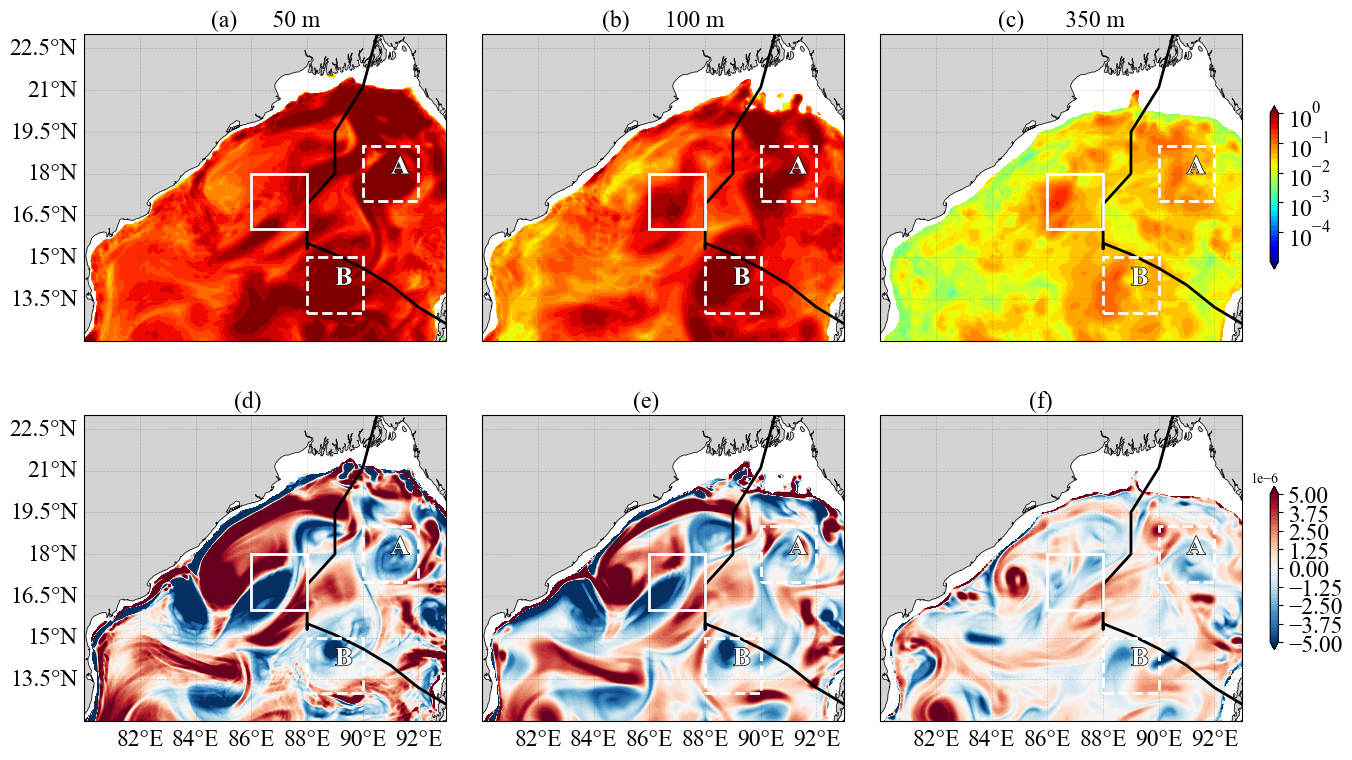

In [70]:
fig,ax = plt.subplots(2,3, figsize=(18,12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=-0.3,wspace=0.1)
axn=ax.flat

vmin = 1e-5
vmax = 1e0
lev = np.logspace(-5, 0, 30)
norm = plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
pl=EKE_sitrang_50.plot.contourf(ax=axn[0],add_colorbar=False,levels=lev, norm=norm,cmap='jet',extend='both')
EKE_sitrang_100.plot.contourf(ax=axn[1],add_colorbar=False,levels=lev, norm=norm,cmap='jet',extend='both')
EKE_sitrang_300.plot.contourf(ax=axn[2],add_colorbar=False,levels=lev, norm=norm,cmap='jet',extend='both')
cbar=fig.colorbar(pl,ax=ax[0,:],ticks=[1e-4,1e-3,1e-2,1e-1,1,1e1,1e2],shrink=0.3,pad=0.02)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=17)
df = pd.read_csv('/mnt/HDD/IITM/CYCLONE-NIW/bio2022/bio052022.dat', header=None)
lat_track1 = [float(str(i)[1:4])/10 for i in df[6].astype('str')]
lon_track1 = [float(str(i)[1:4]) for i in df[7].astype('str')]


lev=np.arange(-5,5.25,0.25)/1e6
pl=VORT_sitrang_50.plot.contourf(ax=axn[3],add_colorbar=False,levels=lev,extend='both')
VORT_sitrang_100.plot.contourf(ax=axn[4],add_colorbar=False,levels=lev,extend='both')
VORT_sitrang_300.plot.contourf(ax=axn[5],add_colorbar=False,levels=lev,extend='both')
cbar=fig.colorbar(pl,ax=ax[1,:],shrink=0.3,pad=0.02)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=17)

for i in range(6):
    if i < 3:
        axn[i].set_title(['(a)      50 m','(b)      100 m', '(c)       350 m'][i],fontsize=17)
    else:
        axn[i].set_title(['(d)      ','(e)      ', '(f)       '][i-3],fontsize=17)
    fig_beauty(axn[i],2,3,i,17,lc='lightgrey')
    axn[i].plot(lon_track1,lat_track1,color='black',lw=2)
    axn[i].set_extent([80,93,12,23])
    box_map(86,88,16,18,axn[i],c='white',lss='-',lww=2)
    box_map(90,92,17,19,axn[i],c='white',lss='--',lww=2)
    axn[i].text(91, 18, 'A',fontsize=19,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1, foreground='black'),pe.Normal()])
    box_map(88,90,13,15,axn[i],c='white',lss='--',lww=2)
    axn[i].text(89, 14, 'B',fontsize=19,color='white',fontweight='bold',path_effects=[pe.Stroke(linewidth=1, foreground='black'),pe.Normal()])
plt.savefig('Figure_10.jpg',bbox_inches='tight',dpi=800)

## Figure S7

In [41]:
ds_as_1=ren_fun_sck('DATA_MISC/asani/top_box.nc')
ds_as_2=ren_fun_sck('DATA_MISC/asani/asani_point_vel_total_postivevortbox.nc')
ds_as_3=ren_fun_sck('DATA_MISC/asani/asani_point_vel_total_negaticevortbox.nc')

ds_sit_1=ren_fun_sck('DATA_MISC/sitrang/sitrang_point_vel_total_negative_vort.nc')
ds_sit_2=ren_fun_sck('DATA_MISC/sitrang/sitrang_point_vel_total_negative_vort_bottom.nc')


In [42]:
def rot_as(ds):
    ds_uvel = ds.UTOP
    ds_vvel = ds.VTOP

    ds_uvel, ds_vvel = inertial_filter(ds_uvel, ds_vvel, 17)

    CW = []
    CCW = []

    for k in range(41):
        xx, yy, cw, ccw, F = spec_rot(
                ds_uvel.isel(depth=k).sel(time=slice('06-may-2022','28-may-2022')),
                ds_vvel.isel(depth=k).sel(time=slice('06-may-2022','28-may-2022'))
            )

        pos = F > 0
        fq = F[pos]
        cw = cw[pos]
        ccw = ccw[pos]

        CW.append(cw)
        CCW.append(ccw)

    CW_spectrum_sit = xr.DataArray(CW, coords={'depth': ds_uvel.depth, 'F': fq})

    E_cw = np.abs(CW_spectrum_sit)**2

    freq = CW_spectrum_sit['F'].values
    depth = CW_spectrum_sit['depth'].values
    return E_cw,freq,depth

def rot_sit(ds):
    ds_uvel = ds.UTOP
    ds_vvel = ds.VTOP

    ds_uvel, ds_vvel = inertial_filter(ds_uvel, ds_vvel, 17)

    CW = []
    CCW = []

    for k in range(41):
        xx, yy, cw, ccw, F = spec_rot(
                ds_uvel.isel(depth=k).sel(time=slice('22-oct-2022','12-nov-2022')),
                ds_vvel.isel(depth=k).sel(time=slice('22-oct-2022','12-nov-2022'))
            )

        pos = F > 0
        fq = F[pos]
        cw = cw[pos]
        ccw = ccw[pos]

        CW.append(cw)
        CCW.append(ccw)

    CW_spectrum_sit = xr.DataArray(CW, coords={'depth': ds_uvel.depth, 'F': fq})

    E_cw = np.abs(CW_spectrum_sit)**2

    freq = CW_spectrum_sit['F'].values
    depth = CW_spectrum_sit['depth'].values
    return E_cw,freq,depth

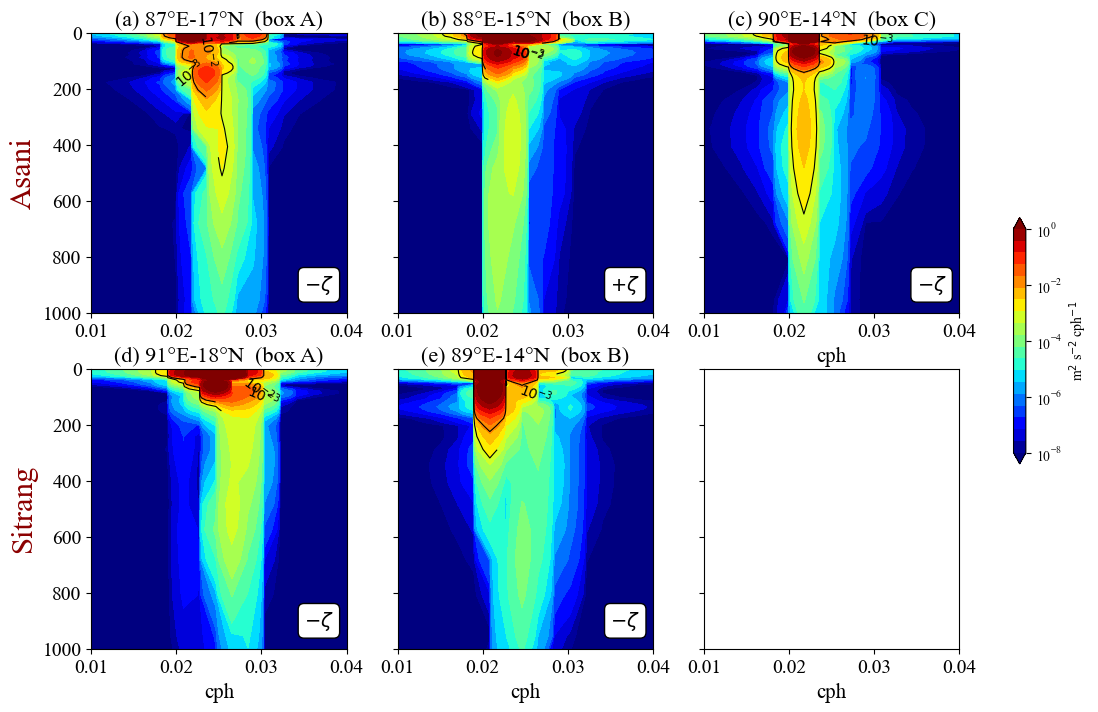

In [43]:
fig,ax=plt.subplots(2,3,figsize=(14,8),sharey=True)

axn=ax.flat

E_cw,freq,depth=rot_as(ds_as_1)
pl=cf = axn[0].contourf(freq, depth, E_cw,levels=np.logspace(-8, 0, 20),norm=plt.matplotlib.colors.LogNorm(),cmap='jet',extend='both')
cfn = axn[0].contour(freq, depth, E_cw,levels=[0.001, 0.01],norm=plt.matplotlib.colors.LogNorm(),colors='black',linewidths=0.8)
axn[0].clabel(cfn, fmt=lambda x: rf'$10^{{{int(np.log10(x))}}}$',fontsize=10)
axn[0].text(0.035, 920,r'$-\zeta$',color='black',fontsize=14,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

E_cw,freq,depth=rot_as(ds_as_2)
cf = axn[1].contourf(freq, depth, E_cw,levels=np.logspace(-8, 0, 20),norm=plt.matplotlib.colors.LogNorm(),cmap='jet',extend='both')
cfn = axn[1].contour(freq, depth, E_cw,levels=[0.001, 0.01],norm=plt.matplotlib.colors.LogNorm(),colors='black',linewidths=0.8)
axn[1].clabel(cfn, fmt=lambda x: rf'$10^{{{int(np.log10(x))}}}$',fontsize=10)
axn[1].text(0.035, 920,r'$+\zeta$',color='black',fontsize=14,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

E_cw,freq,depth=rot_as(ds_as_3)
cf = axn[2].contourf(freq, depth, E_cw,levels=np.logspace(-8, 0, 20),norm=plt.matplotlib.colors.LogNorm(),cmap='jet',extend='both')
cfn = axn[2].contour(freq, depth, E_cw,levels=[0.001, 0.01],norm=plt.matplotlib.colors.LogNorm(),colors='black',linewidths=0.8)
axn[2].clabel(cfn, fmt=lambda x: rf'$10^{{{int(np.log10(x))}}}$',fontsize=10)
axn[2].text(0.035, 920,r'$-\zeta$',color='black',fontsize=14,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

E_cw,freq,depth=rot_sit(ds_sit_1)
cf = axn[3].contourf(freq, depth, E_cw,levels=np.logspace(-8, 0, 20),norm=plt.matplotlib.colors.LogNorm(),cmap='jet',extend='both')
cfn = axn[3].contour(freq, depth, E_cw,levels=[0.001, 0.01],norm=plt.matplotlib.colors.LogNorm(),colors='black',linewidths=0.8)
axn[3].clabel(cfn, fmt=lambda x: rf'$10^{{{int(np.log10(x))}}}$',fontsize=10)
axn[3].text(0.035, 920,r'$-\zeta$',color='black',fontsize=14,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

E_cw,freq,depth=rot_sit(ds_sit_2)
cf = axn[4].contourf(freq, depth, E_cw,levels=np.logspace(-8, 0, 20),norm=plt.matplotlib.colors.LogNorm(),cmap='jet',extend='both')
cfn = axn[4].contour(freq, depth, E_cw,levels=[0.001, 0.01],norm=plt.matplotlib.colors.LogNorm(),colors='black',linewidths=0.8)
axn[4].clabel(cfn, fmt=lambda x: rf'$10^{{{int(np.log10(x))}}}$',fontsize=10)
axn[4].text(0.035, 920,r'$-\zeta$',color='black',fontsize=14,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

titl=['(a) 87°E-17°N  (box A)','(b) 88°E-15°N  (box B)','(c) 90°E-14°N  (box C)','(d) 91°E-18°N  (box A)','(e) 89°E-14°N  (box B)','']
        
axn[0].set_ylim(1000,0)
for i in range(6):
    axn[i].set_xlim(0.01,0.04)
    axn[i].tick_params(axis='both',labelsize=14)
    axn[i].set_title(titl[i],fontsize=16)
    if i > 1:
        axn[i].set_xlabel('cph',fontsize=15)
axn[0].set_ylabel('Asani',fontsize=22,color='darkred')
axn[3].set_ylabel('Sitrang',fontsize=22,color='darkred')

cbar=fig.colorbar(pl, ax=ax[:,:], ticks=[1e-8,1e-6,1e-4,1e-2,1e0,1e2],shrink=0.4,pad=0.05)
axn=ax.flat
cbar.set_label(r'm$^2$ s$^{-2}$ cph$^{-1}$')
plt.savefig('FIGURE/Figure_SX.pdf',bbox_inches='tight',dpi=800)

In [111]:
utop_83=xr.open_dataset('wavelet/asani_85.nc').UTOP_85.squeeze().rename({'YH679_988':'lat','ZH_L':'depth','TIME':'time'})
vtop_83=xr.open_dataset('wavelet/asani_85.nc').VTOP_85.squeeze().rename({'YQ679_989':'lat','ZH_L':'depth','TIME':'time'}).interp(lat=utop_83.lat)

In [139]:
import numpy as np
import pywt

def compute_ni_wavelet_lat_time(utop, vtop, depth_level, scales=np.arange(5,200), dt=6/24):

    omega_earth = 7.2921e-5

    lats = utop.lat.values
    times = utop.time.values

    NI_all = np.zeros((len(lats), len(times)))

    wavelet = 'cmor1.5-1.0'

    for j, lat1 in enumerate(lats):

        U = (
            utop.sel(lat=lat1, depth=depth_level, method='nearest').values
            + 1j *
            vtop.sel(lat=lat1, depth=depth_level, method='nearest').values
        )

        U = U - np.nanmean(U)

        coeffs, freqs = pywt.cwt(
            U,
            scales,
            wavelet,
            sampling_period=dt
        )

        phi = np.deg2rad(lat1)

        f = 2 * omega_earth * np.sin(phi)

        f_cpd = (f/(2*np.pi))*86400

        idx = (freqs >= 0.8*f_cpd) & (freqs <= 1.2*f_cpd)

        power = np.abs(coeffs)**2

        NI_all[j, :] = np.sum(power[idx, :], axis=0).real

    return NI_all, lats, times


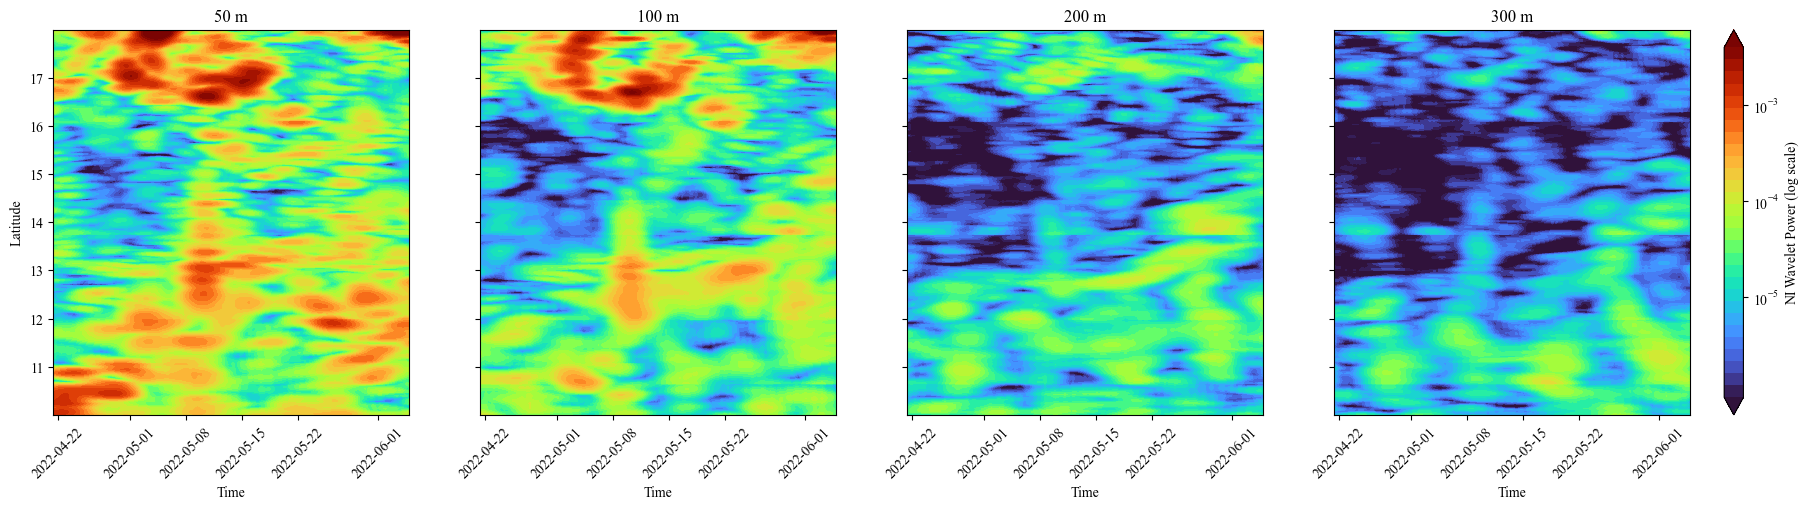

In [146]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np

depths = [50, 100, 200, 300]

results = []

for d in depths:
    NI_all, lats, times = compute_ni_wavelet_lat_time(utop_83, vtop_83, d)
    NI_all[NI_all <= 0] = np.nan
    results.append(NI_all)

all_valid = np.concatenate([r[np.isfinite(r)] for r in results])

vmin = np.nanpercentile(all_valid, 5)
vmax = np.nanpercentile(all_valid, 99)

levels = np.logspace(np.log10(vmin), np.log10(vmax), 30)

fig, axs = plt.subplots(1, 4, figsize=(22, 5), sharey=True, sharex=True)

for i, d in enumerate(depths):

    cf = axs[i].contourf(
        times,
        lats,
        results[i],
        levels=levels,
        norm=LogNorm(vmin=vmin, vmax=vmax),
        cmap='turbo',
        extend='both'
    )

    axs[i].set_title(f'{d} m')
    axs[i].set_xlabel('Time')
    axs[i].set_xlim(times[25],times[-25])
    axs[i].tick_params(axis='x',rotation=45)

axs[0].set_ylabel('Latitude')

cbar = fig.colorbar(cf, ax=axs, orientation='vertical', fraction=0.02, pad=0.02,ticks=[1e-5,1e-4,1e-3,1e-2,1e-1])
cbar.set_label('NI Wavelet Power (log scale)')
plt.savefig('Wavelet_85.jpg',bbox_inches='tight',dpi=500)